<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>BHs in Binaries</p>
    <o style='font-size:20px;'>This notebook explores how BHs in binaries are different from the isolated population</p>
</div>

In [1]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload
import warnings
import os

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
files = ["fiducial"]
labels = ["Fiducial"]
colours = ["#333"]

pops, data = helpers.load_postprocessed_pops(files, labels, colours)

Loading post-processed data for Fiducial from fiducial


In [ ]:
KNOWN_BHS = {
    "isolated": [
        {
            "name": "OGLE-2011-BLG-0462",
            "mass": 7.15,
            "mass_error": 0.83,
        }
    ],
    "bh-stars": [
        {
            "name": "Gaia BH1",
            "mass": 9.27,
            "mass_error": 0.1,
            "period": 185.387,
        },
        {
            "name": "Gaia BH2",
            "mass": 8.94,
            "mass_error": 0.34,
            "period": 1276.7,
        },
        {
            "name": "Gaia BH3",
            "mass": 33.08,
            "mass_error": 0.48,
            "period": 11.57 * 365.25,
            "period_error:": 0.25 * 365.25,
            "zmax": 
        }
    ]
}

In [3]:
if os.path.exists("/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_star.h5"):
    print("Loading pre-processed co-star population from fiducial_co_star.h5")
    co_pop = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_star.h5")
    co_pop.orbits
    bh_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 14]
    ns_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 13]
else:
    print("Processing co-star population from fiducial_co_plus_star_part*.h5 files")
    with warnings.catch_warnings(category=FutureWarning):
        warnings.simplefilter("ignore")
        co_pops = [cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_plus_star_part{i}.h5") for i in range(100)]

    [(pop.final_pos, pop.orbits) for pop in co_pops]
    with warnings.catch_warnings(category=FutureWarning):
        warnings.simplefilter("ignore")
        co_pop = sum(co_pops[1:], start=co_pops[0])

    co_pop.final_pos
    co_pop.orbits
    co_pop.save("/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_star.h5", overwrite=True)
    bh_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 14]
    ns_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 13]

Loading pre-processed co-star population from fiducial_co_star.h5


In [88]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_wd = bound & (data["Fiducial"]["companion"]["BH"] >= 10) & (data["Fiducial"]["companion"]["BH"] <= 12)
bh_star = bound & (data["Fiducial"]["companion"]["BH"] >= 0) & (data["Fiducial"]["companion"]["BH"] <= 10)
bh_ns = bound & (data["Fiducial"]["companion"]["BH"] == 13)
bh_bh = bound & (data["Fiducial"]["companion"]["BH"] == 14) & (data["Fiducial"]["primary"]["BH"])
bh_bh_secondary = bound & (data["Fiducial"]["companion"]["BH"] == 14) & ~(data["Fiducial"]["primary"]["BH"])

# Mass distribution

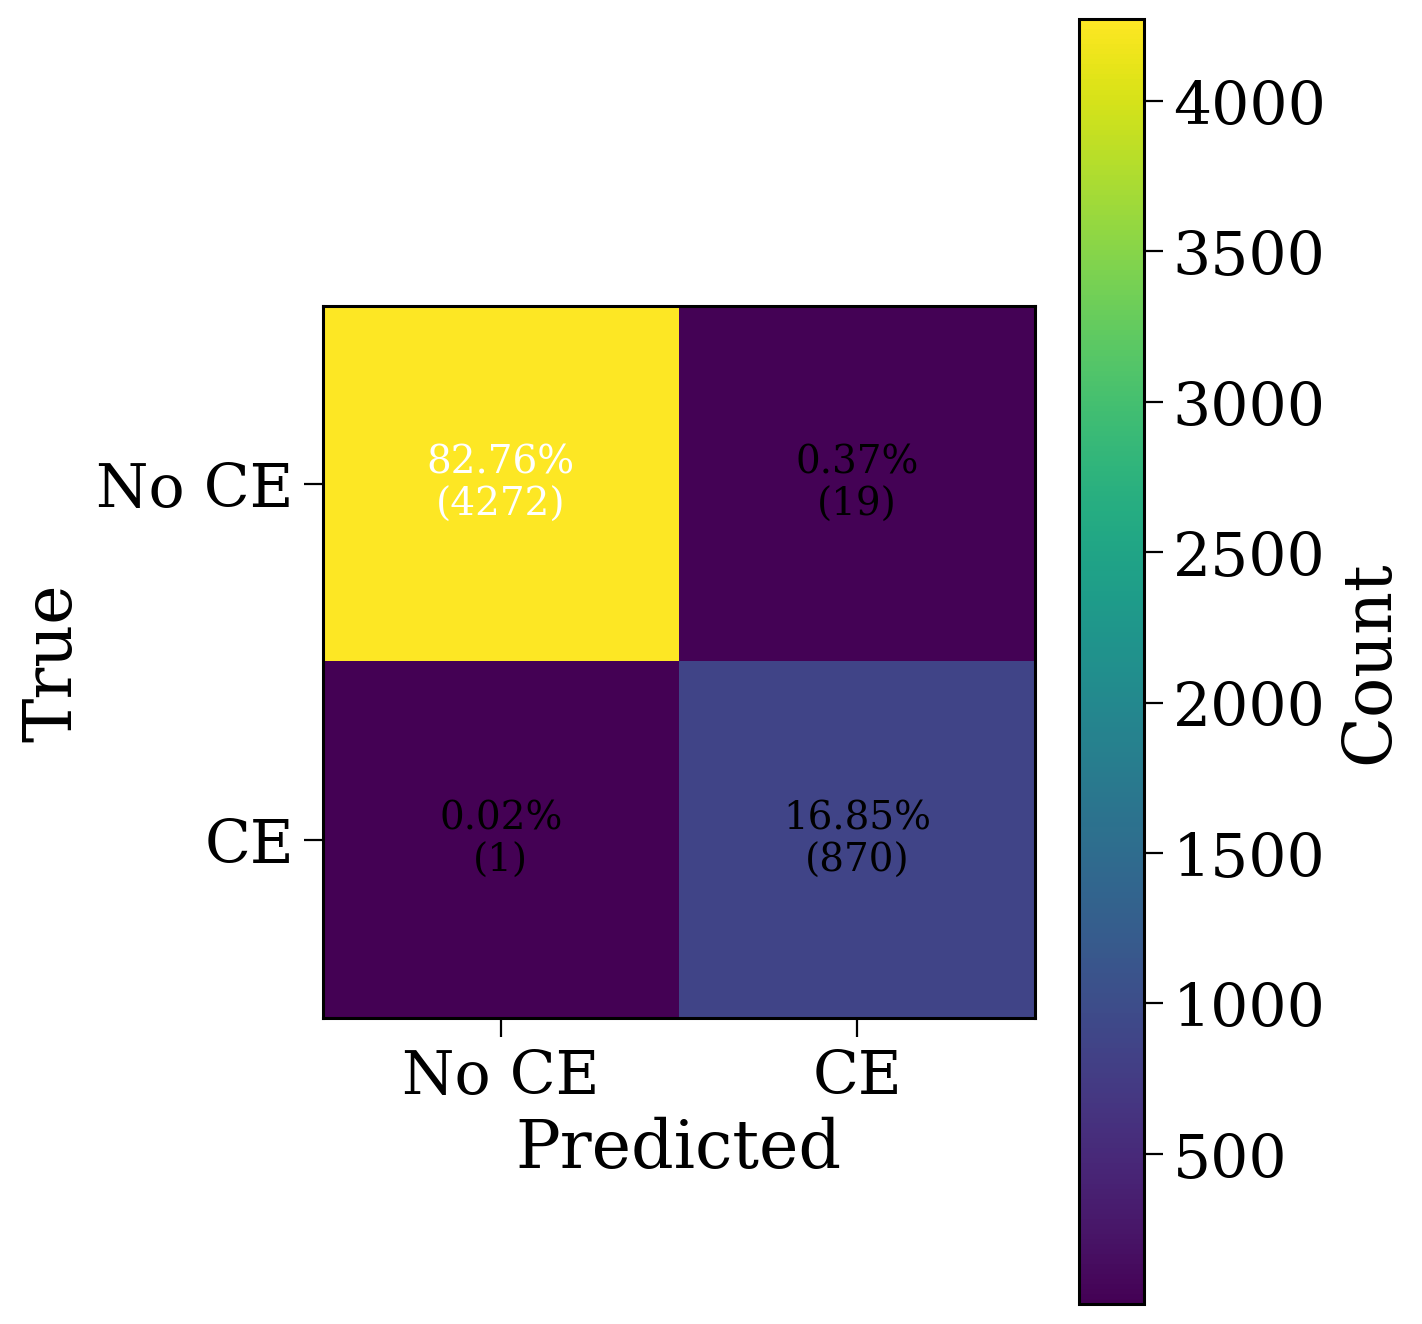

In [91]:
def mt_sep_line(bh_mass):
    # power law that passes through xy=(3, 1e4) and (50, 20)
    return 7e3 * (bh_mass / 3)**(-2.2)

had_ce = np.isin(bh_star_pop.bin_nums, bh_star_pop.bpp[bh_star_pop.bpp["evol_type"] == 7]["bin_num"])
had_ce_from_line = bh_star_pop.final_bpp["porb"] < mt_sep_line(bh_star_pop.final_bpp["mass_1"])

# Boolean arrays

truth = np.asarray(had_ce, dtype=bool)
pred = np.asarray(had_ce_from_line, dtype=bool)

# Confusion matrix counts

tp = np.sum(truth & pred)
tn = np.sum(~truth & ~pred)
fp = np.sum(~truth & pred)
fn = np.sum(truth & ~pred)
cm = np.array([[tn, fp],
               [fn, tp]])

fig, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(cm)

# Labels

ax.set_xticks([0, 1], labels=["No CE", "CE"])

ax.set_yticks([0, 1], labels=["No CE", "CE"])

ax.set_xlabel("Predicted")

ax.set_ylabel("True")

# Write counts

for i in range(2):

    for j in range(2):

        ax.text(

            j, i, f"{cm[i, j] / cm.sum():.2%}\n({cm[i, j]})",

            ha="center", va="center",

            color="white" if cm[i, j] > cm.max()/2 else "black",

            fontsize=14

        )

# Optional colorbar

fig.colorbar(im, ax=ax, label="Count")

plt.tight_layout()

plt.show()

Gaia BH1 9.27 185.387
Gaia BH2 8.94 1276.7
Gaia BH3 33.08 4225.9425


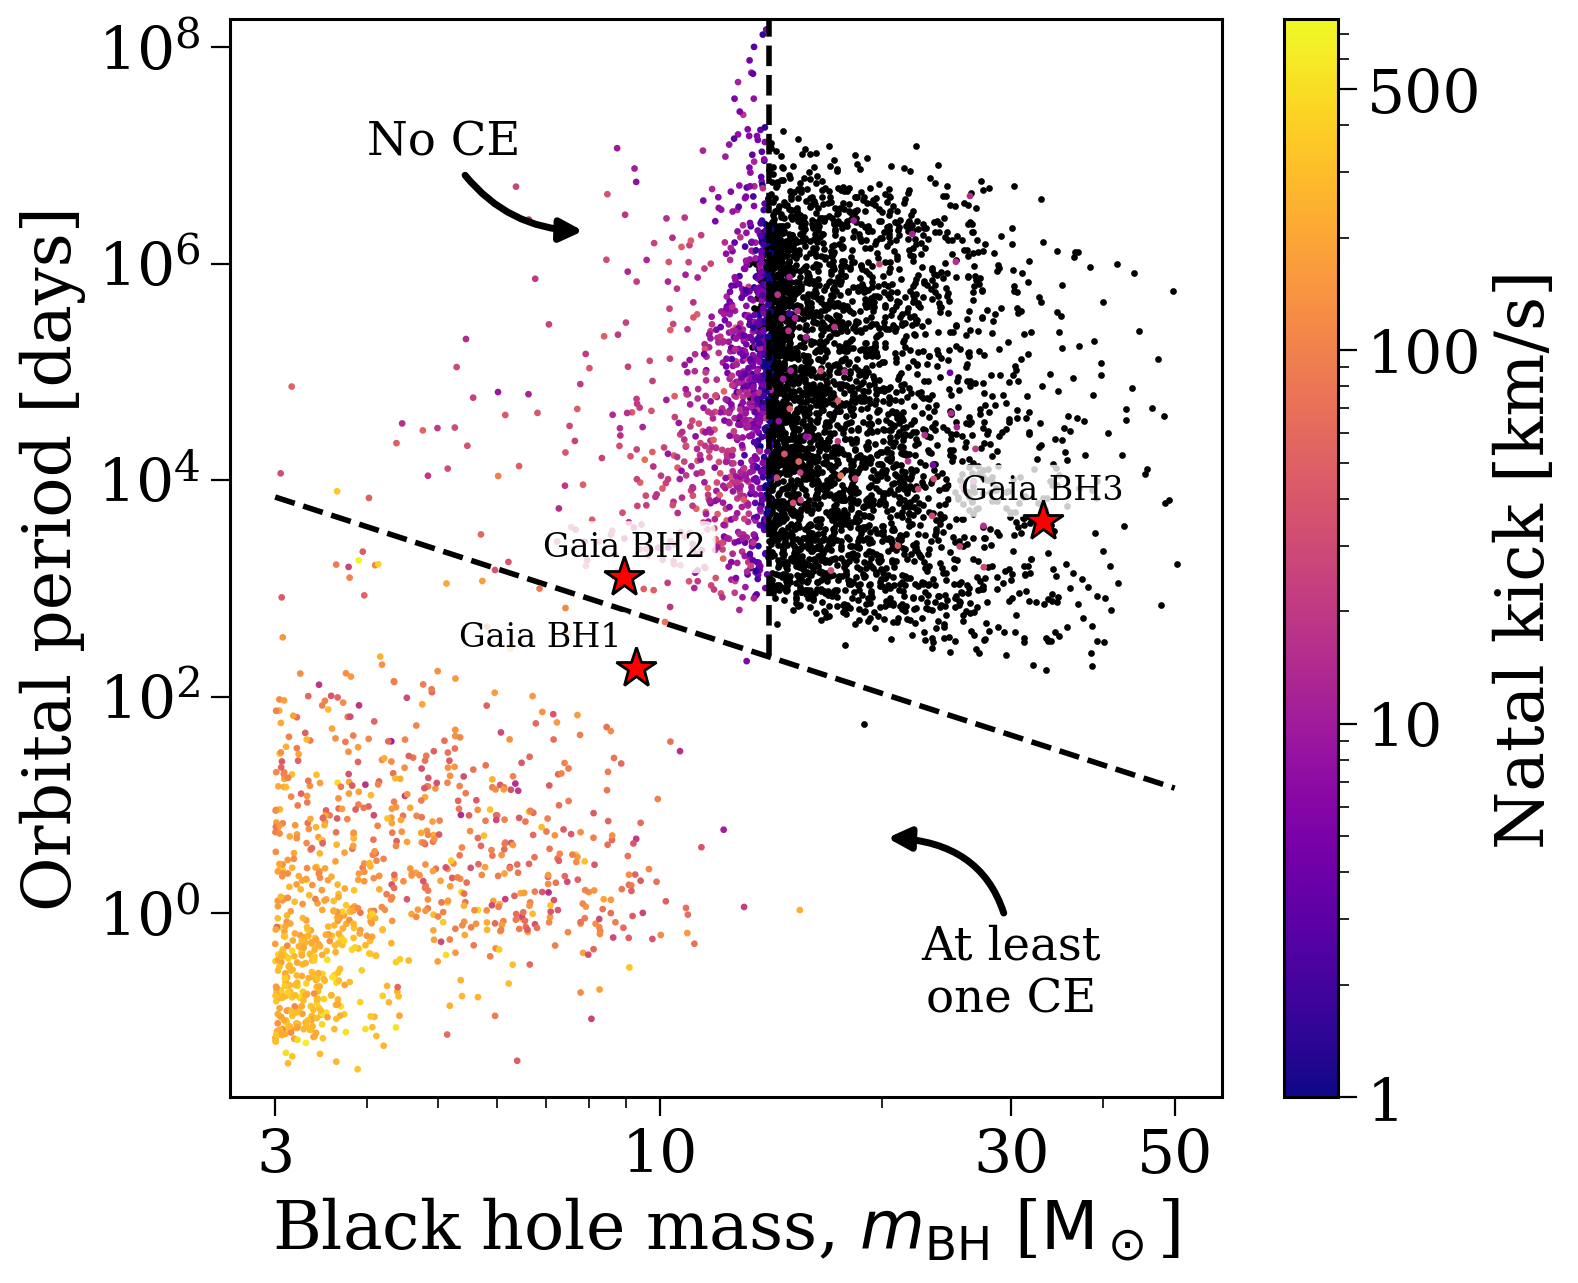

In [87]:
fig, ax = plt.subplots(figsize=(8, 7))

# had_ce = np.isin(bh_star_pop.bin_nums, bh_star_pop.bpp[bh_star_pop.bpp["evol_type"] == 3]["bin_num"])
# plt.scatter(bh_star_pop.final_bpp["mass_1"], bh_star_pop.final_bpp["porb"], c=had_ce, s=5)

kick_strength = bh_star_pop.kick_info[bh_star_pop.kick_info["star"] == 1]["natal_kick"]
got_kicked = kick_strength > 0
ax.scatter(bh_star_pop.final_bpp["mass_1"][~got_kicked], bh_star_pop.final_bpp["porb"][~got_kicked], c='k', s=2, rasterized=True)
scatter = ax.scatter(bh_star_pop.final_bpp["mass_1"][got_kicked], bh_star_pop.final_bpp["porb"][got_kicked], c=kick_strength[got_kicked], s=2, norm=mpl.colors.LogNorm(vmin=1), cmap="plasma", rasterized=True)

# inset_ax = ax.inset_axes([0.05, 0.85, 0.6, 0.1])

cbar = fig.colorbar(scatter, label="Natal kick [km/s]", format="%.0f")
cbar.set_ticks([1, 10, 100, 500], labels=[1, 10, 100, 500])

for bh in KNOWN_BHS["bh-stars"]:
    print(bh["name"], bh["mass"], bh["period"])
    ax.errorbar(bh["mass"], bh["period"], xerr=bh["mass_error"], fmt='*', c='r', ms=15, mew=1, mec='k', zorder=20)
    ax.annotate(bh["name"], xy=(bh["mass"], bh["period"]), xytext=(-5 if bh["name"] == "Gaia BH1" else 0, 5),
                textcoords='offset points', fontsize=0.5*fs, ha='right' if bh["name"] == "Gaia BH1" else 'center',
                va='bottom', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel="Orbital period [days]",
    xscale='log',
    yscale="log",
    ylim=(2e-2, 1.8e8)
)

# ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.set_xticks([3, 10, 30, 50], labels=[3, 10, 30, 50])

# add an annotation in the lower right corner with an arc arrow that points diagonally up left
ax.annotate("At least\none CE", xy=(20, 5), xytext=(30, 0.8), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, connectionstyle="arc3,rad=0.5"), fontsize=0.7*fs, ha='center', va='top')
ax.annotate("No CE", xy=(8, 2e6), xytext=(4, 1e7), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, connectionstyle="arc3,rad=0.3"), fontsize=0.7*fs)

def mt_sep_line(bh_mass):
    # power law that passes through xy=(3, 1e4) and (50, 20)
    return 7e3 * (bh_mass / 3)**(-2.2)

mass_range = np.linspace(3, 50, 100)
ax.plot(mass_range, mt_sep_line(mass_range), ls='--', c='k', lw=2, zorder=-1)



# diagonal dashed line
ax.axvline(14.04, 0.41, ls='--', c='k', lw=2, zorder=10)

plt.savefig("../plots/bh_star_mbh_vs_porb.pdf", bbox_inches='tight', format='pdf')
plt.show()

10453
Fraction likely detectable as binaries 13.34%


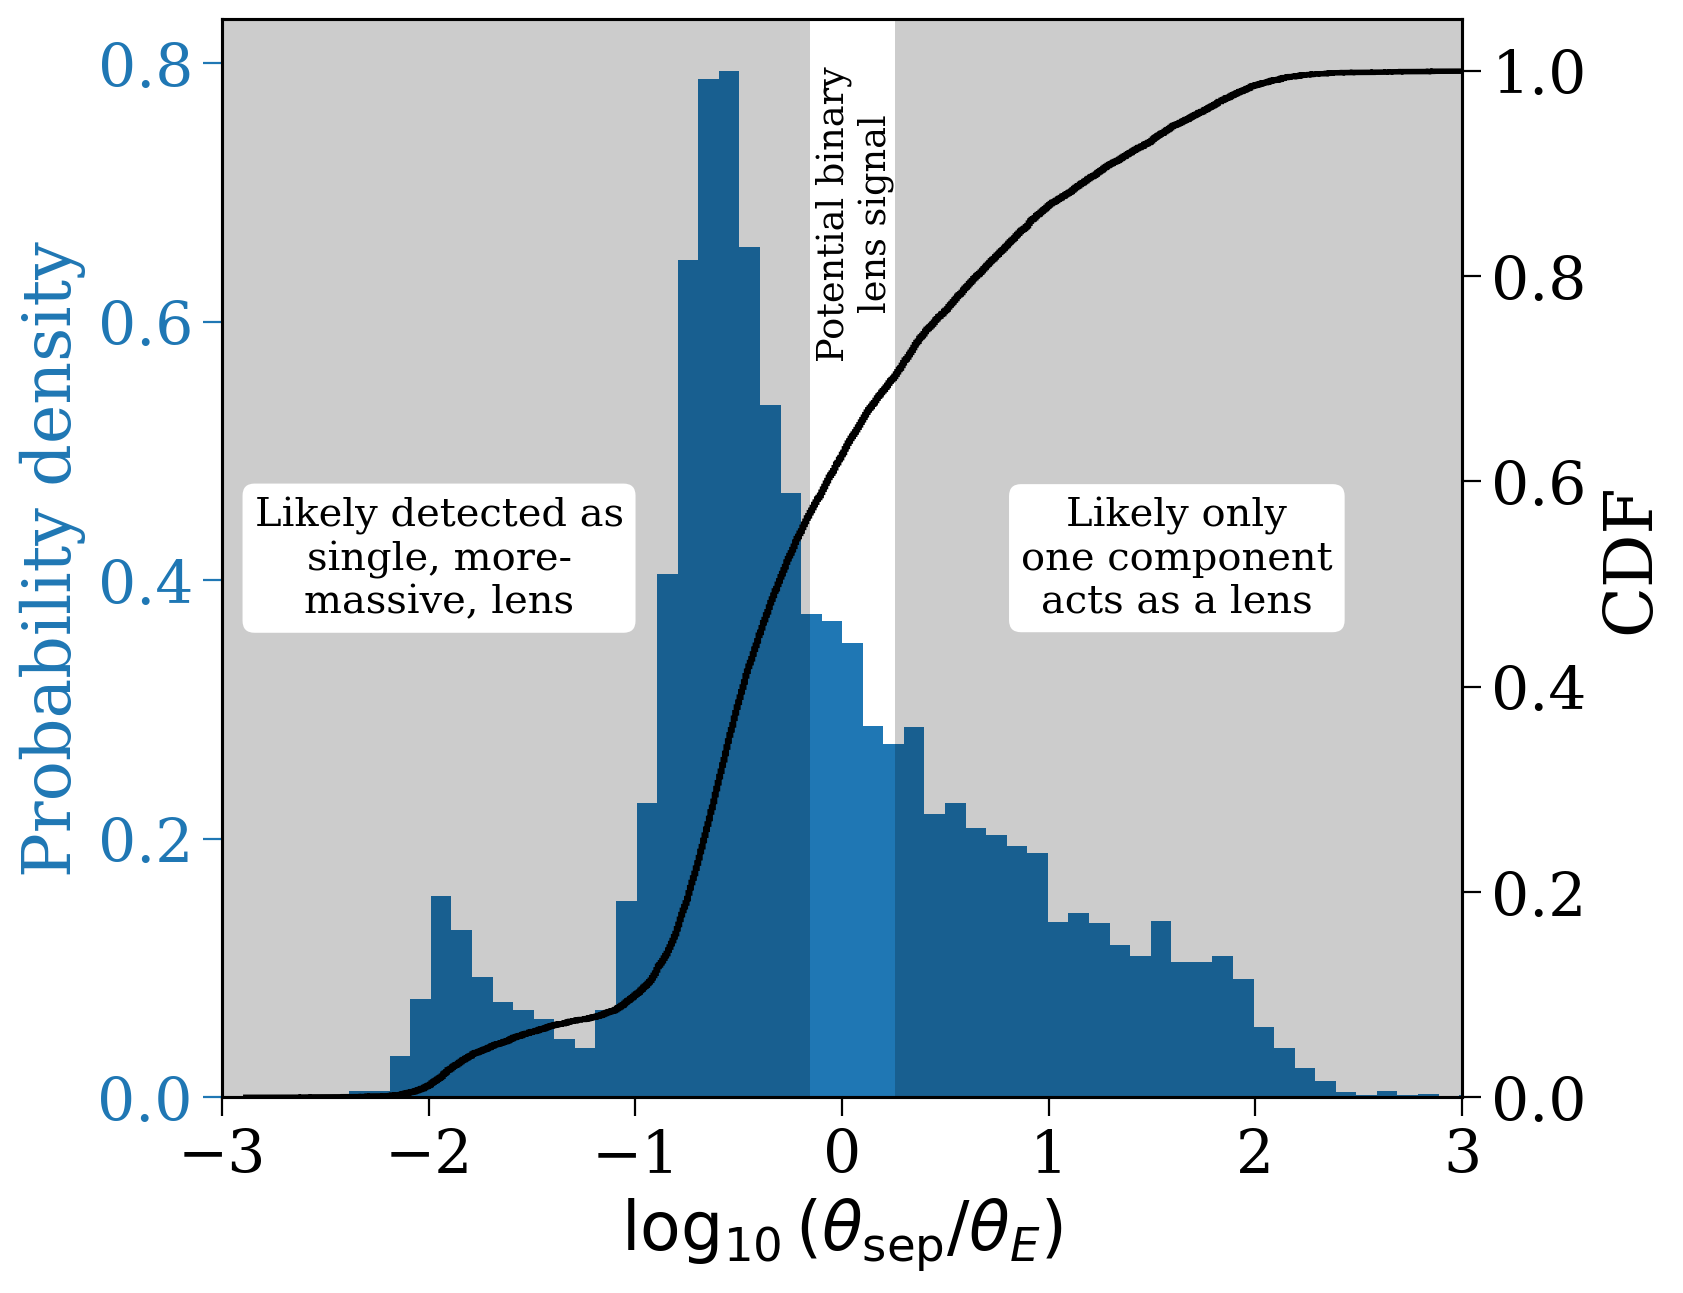

In [106]:
import astropy.units as u
import astropy.constants as astro_consts

def is_towards_bulge(pos):
    R = np.linalg.norm(pos[:, :2], axis=1)
    z = pos[:, 2]
    return (R < 8.2) & (abs(z) < abs(R - 8.2) * np.tan(np.radians(5)))

def distance_to_sun_ring(pos):
    # assume the sun is anywhere on a ring at 8.2kpc and z=0
    R = np.linalg.norm(pos[:, :2], axis=1)
    z = pos[:, 2]
    return np.sqrt((R - 8.2)**2 + z**2)

def approximate_einstein_radius(total_mass, distance, assumed_source_distance=8.2 * u.kpc):
    return np.sqrt(4 * astro_consts.G * total_mass / astro_consts.c**2 * (1 / distance - 1 / assumed_source_distance)).decompose()

theta_e = approximate_einstein_radius(
    total_mass=(data["Fiducial"]["mass"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])] + data["Fiducial"]["mass"]["BH"][bh_bh_secondary & is_towards_bulge(data["Fiducial"]["pos"]["BH"])]) * u.Msun,
    distance=distance_to_sun_ring(data["Fiducial"]["pos"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])]) * u.kpc
)

angular_sep = data["Fiducial"]["sep"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])] * u.Rsun / (distance_to_sun_ring(data["Fiducial"]["pos"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])]) * u.kpc).to(u.Rsun)

fig, ax = plt.subplots(figsize=(8, 7))

print((~np.isnan(theta_e)).sum())

ratio = angular_sep / theta_e

ax.hist(np.log10(angular_sep / theta_e), bins="auto", density=True)

ax_right = ax.twinx()
ax_right.hist(np.log10(angular_sep / theta_e), bins=1000, cumulative=True, density=True, histtype="step", color='k', lw=2)

ax.set(
    xlabel=r"$\log_{10}(\theta_{\rm sep} / \theta_E)$",
    xlim=(-3, 3),
)
# change ticks and ylabel font colour
ax.tick_params(axis='y', colors='tab:blue')
ax.set_ylabel("Probability density", color='tab:blue')

ax_right.set(
    ylabel="CDF"
)

# ax.axvline(0, ls='--', c='k', lw=1)
ax.axvspan(-3, np.log10(0.7), color='k', alpha=0.2, lw=0)
ax.axvspan(np.log10(1.8), 3, color='k', alpha=0.2, lw=0)
# ax.annotate("BHBH", xy=(0.02, 0.97), xycoords='axes fraction', ha='left', va='top', fontsize=0.8*fs, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"))

ax.annotate("Likely detected as\nsingle, more-\nmassive, lens", xy=(0.175, 0.5), xycoords='axes fraction', ha='center', va='center', fontsize=0.6*fs, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"))
ax.annotate("Likely only\none component\nacts as a lens", xy=(0.77, 0.5), xycoords='axes fraction', ha='center', va='center', fontsize=0.6*fs, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"))
ax.annotate("Potential binary\nlens signal", xy=(0.51, 0.82), xycoords='axes fraction', ha='center', va='center', fontsize=0.55*fs, bbox=dict(boxstyle="round,pad=0.0", fc="white", ec="none"), rotation=90)

binary_lens = ((ratio > 0.7) & (ratio < 1.8))
print(f"Fraction likely detectable as binaries {binary_lens.sum() / len(ratio):.2%}")

plt.savefig("../plots/bh_binary_lenses.pdf", bbox_inches='tight', format='pdf')

plt.show()


[Text(0.5, 0, 'Black hole mass, $m_{\\mathrm{BH}}$ [$\\rm M_\\odot$]'),
 Text(0, 0.5, 'Semi-major axis, $a \\, [\\rm R_\\odot]$')]

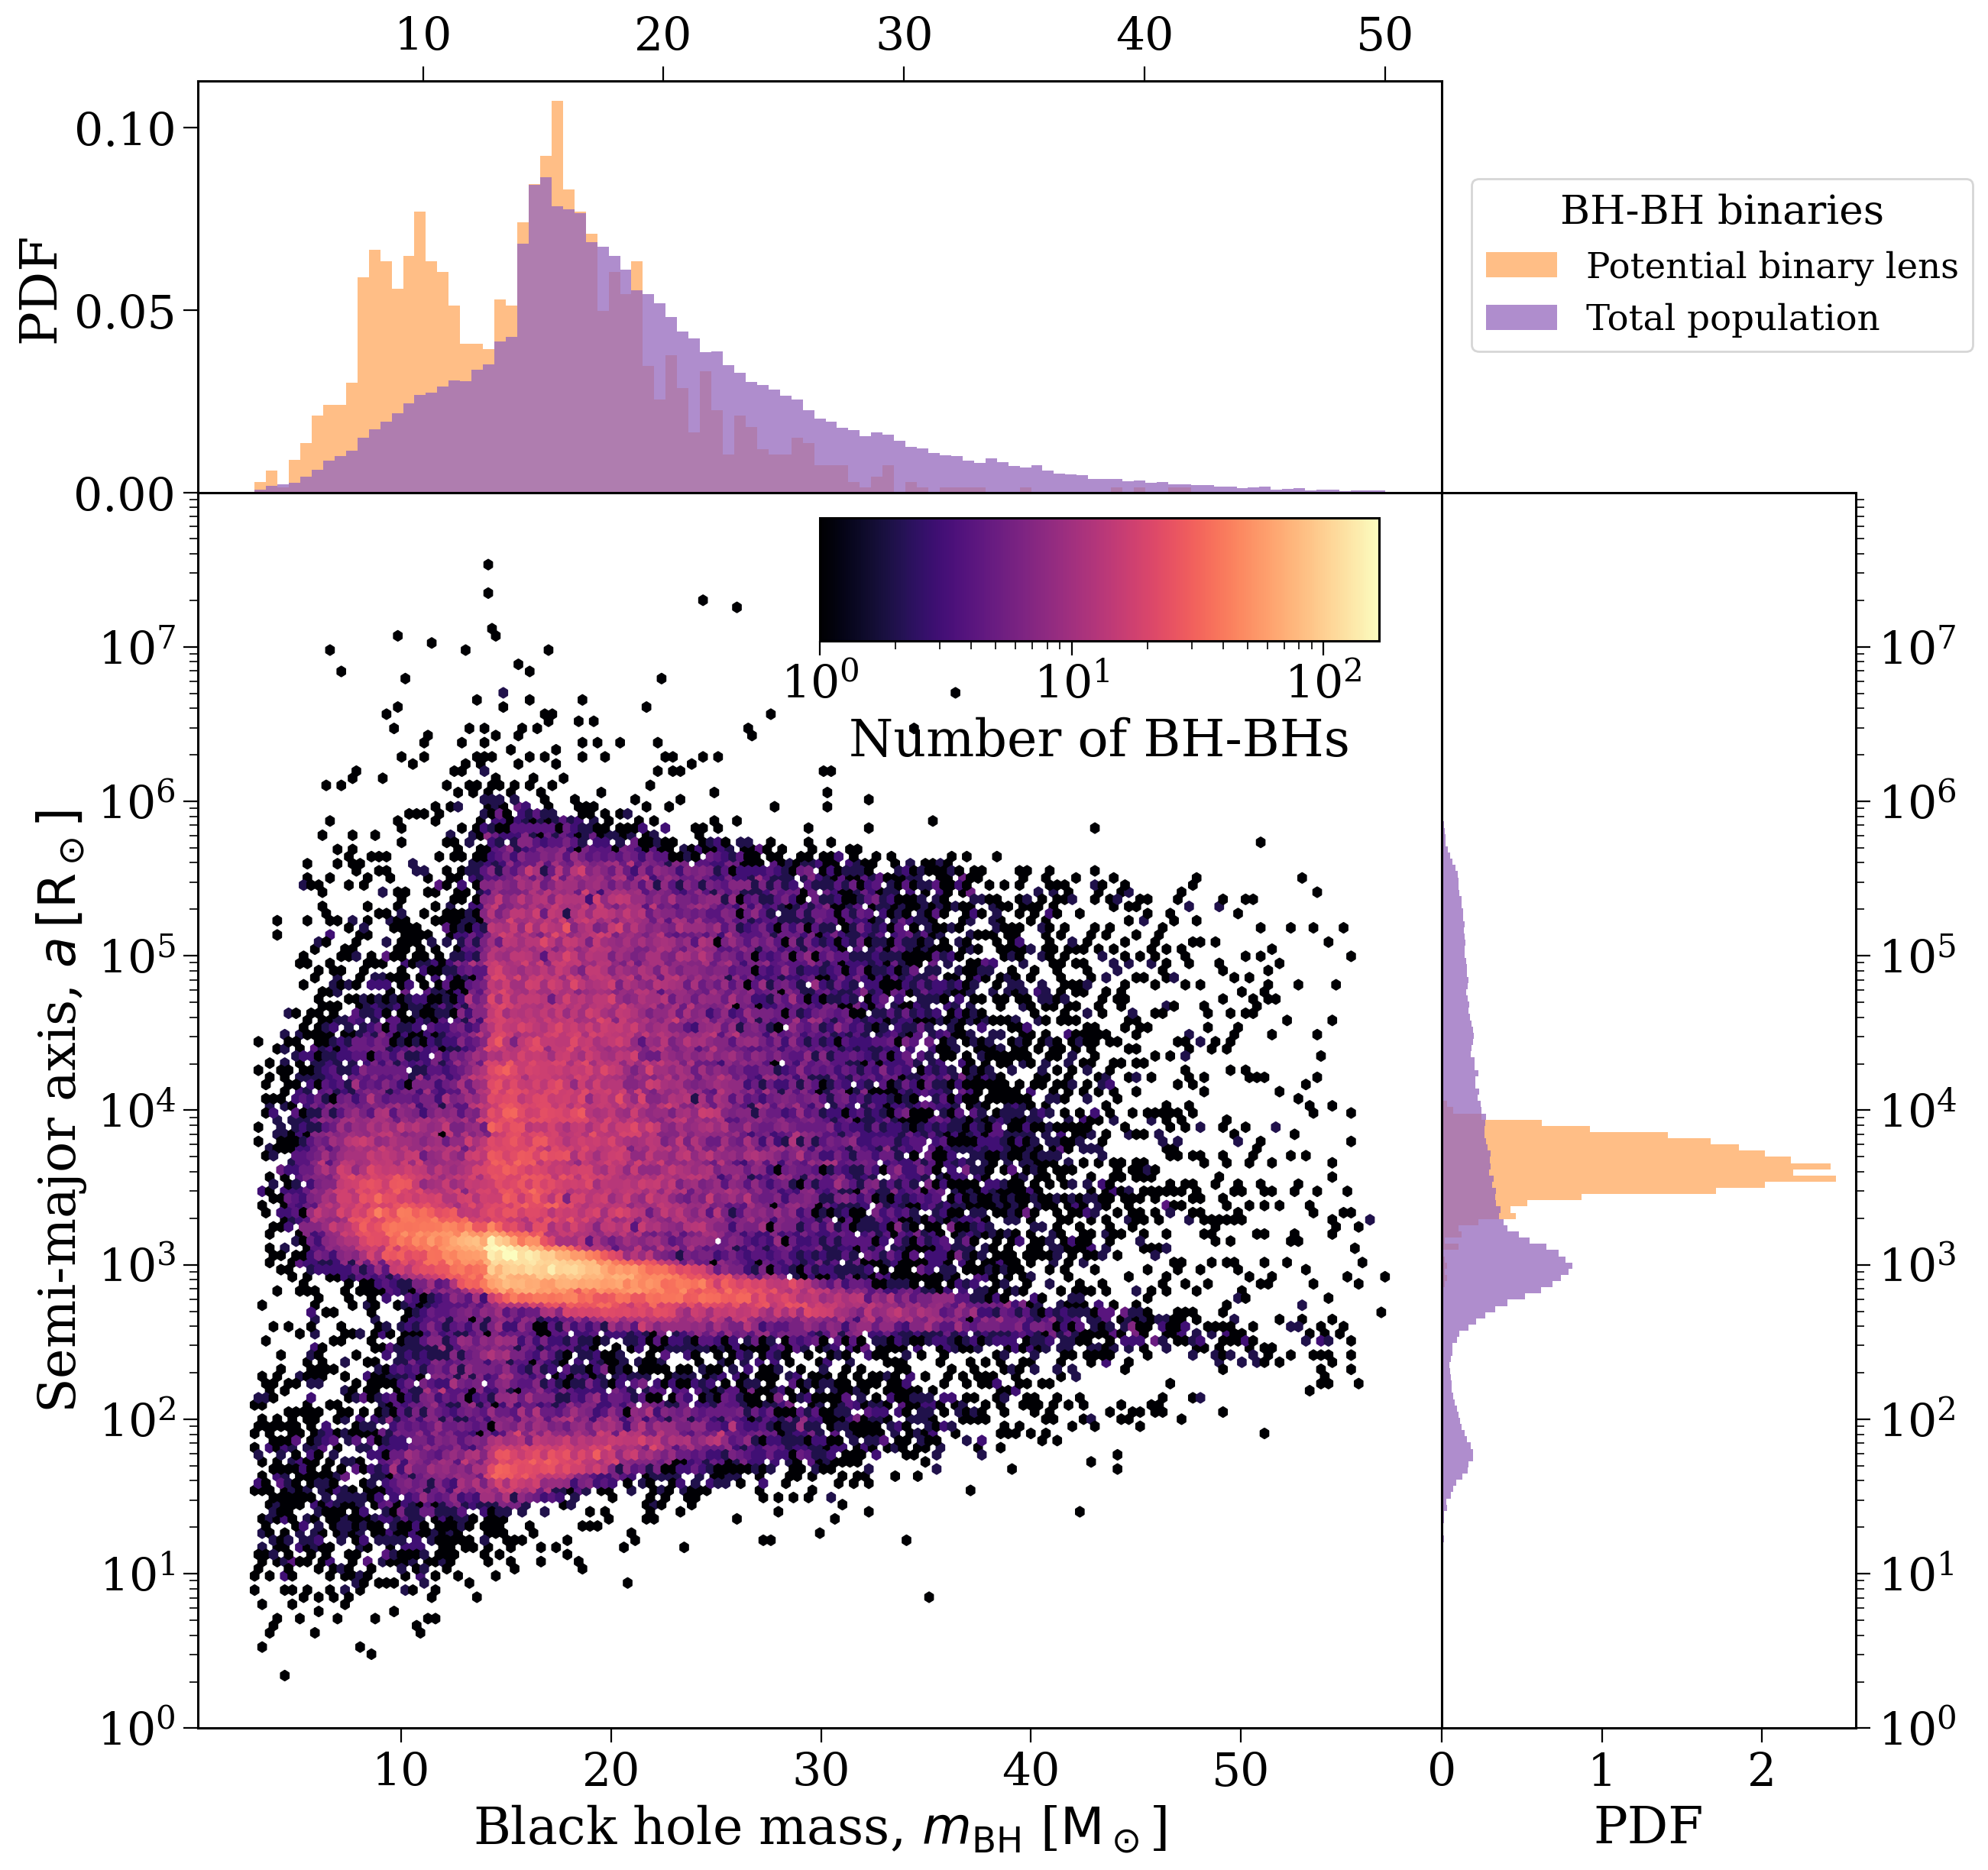

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), gridspec_kw={"width_ratios": [3, 1], "height_ratios": [1, 3]})

fig.subplots_adjust(hspace=0.0, wspace=0.0)

bound = data["Fiducial"]["sep"]["BH"] > 0
bh_bh = bound & (data["Fiducial"]["companion"]["BH"] == 14) & (data["Fiducial"]["primary"]["BH"])

axes[0, 0].hist(data["Fiducial"]["mass"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])][binary_lens], bins=np.linspace(3, 50, 100), color="tab:orange", density=True, alpha=0.5)
axes[0, 0].hist(data["Fiducial"]["mass"]["BH"][bh_bh], bins=np.linspace(3, 50, 100), color="tab:purple", density=True, alpha=0.75)
axes[0, 0].set(
    ylabel="PDF",
)
axes[0, 0].xaxis.tick_top()
hexbin = axes[1, 0].hexbin(
    data["Fiducial"]["mass"]["BH"][bh_bh],
    data["Fiducial"]["sep"]["BH"][bh_bh],
    bins="log", yscale="log", cmap="magma", gridsize=150,
)

# axes[1, 0].scatter(
#     data["Fiducial"]["mass"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])][binary_lens],
#     data["Fiducial"]["sep"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])][binary_lens],
#     c="red", s=5, zorder=1000
# )
axes[1, 0].set(
    ylim=(1e0, 9.9e7)
)
inset_ax = axes[1, 0].inset_axes([0.5, 0.88, 0.45, 0.1])
fig.colorbar(hexbin, cax=inset_ax, orientation="horizontal", label="Number of BH-BHs")

def density_hist_log(x, bins, ax, **kwargs):
    counts, edges = np.histogram(x, bins=bins)
    
    log_widths = np.diff(np.log10(edges))
    density = counts / (counts.sum() * log_widths)

    ax.stairs(density, edges, fill=True, **kwargs)
density_hist_log(
    data["Fiducial"]["sep"]["BH"][bh_bh & is_towards_bulge(data["Fiducial"]["pos"]["BH"])][binary_lens],
    bins=np.geomspace(1e0, 1e8, 200),
    color="tab:orange", orientation="horizontal", alpha=0.5, ax=axes[1, 1], label="Potential binary lens"
)
density_hist_log(data["Fiducial"]["sep"]["BH"][bh_bh], bins=np.geomspace(1e0, 1e8, 200),
                color="tab:purple", alpha=0.75, ax=axes[1, 1], orientation="horizontal", label="Total population")
axes[1, 1].set(
    yscale="log",
    # yticks=[],
    # move yticks to right

    ylim=(1e0, 9.9e7),
    xlabel="PDF"
)
axes[1, 1].yaxis.tick_right()
axes[1, 1].legend(loc="lower left", bbox_to_anchor=(0.03, 1.1), title="BH-BH binaries")

axes[0, 1].axis("off")


axes[1, 0].set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Semi-major axis, $a \, [\rm R_\odot]$"
)

Median mass: 6.6
Median mass: 16.4
Median mass: 15.0


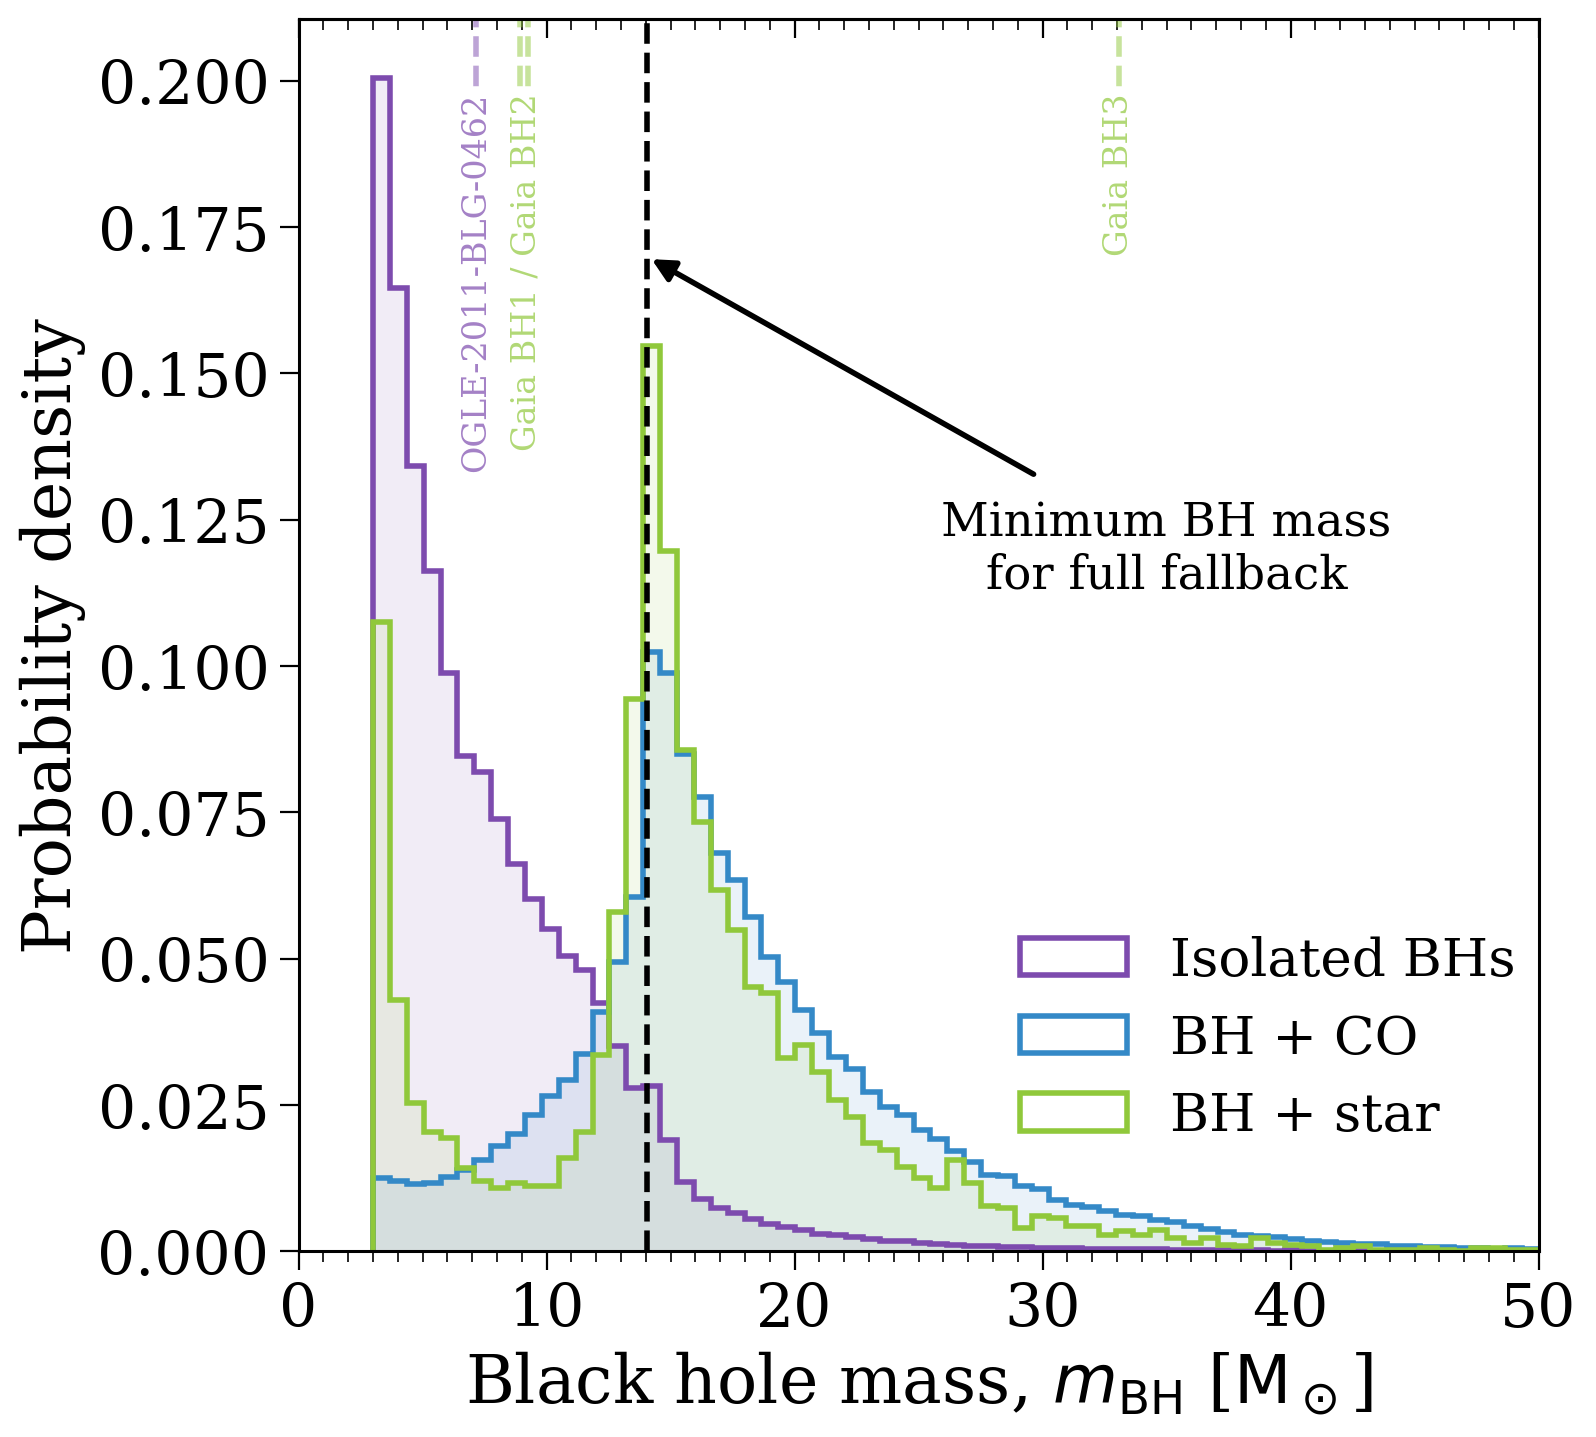

In [123]:
fig, ax = plt.subplots(figsize=(8, 8))

bins = np.linspace(3, 50, 70)
density = True

for masses, colour, label in zip(
    [
        data["Fiducial"]["mass"]["BH"][data["Fiducial"]["sep"]["BH"] <= 0],
        np.concatenate(
            [data["Fiducial"]["mass"]["BH"][bh_bh],
             data["Fiducial"]["mass"]["BH"][bh_bh_secondary],
             data["Fiducial"]["mass"]["BH"][bh_ns],
             data["Fiducial"]["mass"]["BH"][bh_wd]
            ]),
        bh_star_pop.final_bpp["mass_1"],
    ],
    ["#7D4BAE", "#3489C7", "#90C83B"],
    ["Isolated BHs","BH + CO", "BH + star"],
):
    print(f"Median mass: {np.median(masses):1.1f}")
    plotting.nice_transparent_hist(
        ax, data=masses, bins=bins, colour=colour, alpha=0.1, label=label, density=density, lw=2
    )

    # ["Isolated BHs\n(Microlensing)","BH + star\n(Astrometry or XRBs)", "BH + compact object\n(Gravitational waves)"]

ax.axvline(14.04, ls='--', c='k', lw=2)

# ax.annotate("Minimum BH mass\nfor full fallback", xy=(12, 0.14), fontsize=0.6*fs, ha='center', va='center', rotation=90)
# ax.annotate("Minimum BH mass\nfor full fallback", xy=(14.04, 0.18), fontsize=0.5*fs, ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"), rotation=90)
ax.annotate("Minimum BH mass\nfor full fallback", xy=(14.04, 0.17), xytext=(35, 0.12), fontsize=0.7*fs, ha='center', va='center',
            arrowprops=dict(arrowstyle="-|>", color='k', lw=2), bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="none"))

ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

leg = ax.legend(fontsize=0.8*fs, frameon=False, loc='lower right', bbox_to_anchor=(1.02, 0.05))#, labelspacing=1.2)

# add vertical lines with annotations on the top of the plot for known BHs in the right colours
for known_group, col in zip(KNOWN_BHS.keys(), ["#7D4BAE", "#90C83B"]):
    for known in KNOWN_BHS[known_group]:
        ax.axvline(known["mass"], 0.85, 1, ls='--', c=col, lw=2, alpha=0.5)

        label_height = 0.198

        if known["name"] == "Gaia BH1":
            continue
        elif known["name"] == "Gaia BH2":
            ax.annotate("Gaia BH1 / Gaia BH2", xy=(9.2, label_height), xytext=(9.2, label_height),
                        fontsize=0.5*fs, ha='center', va='top',
                        bbox=dict(boxstyle="round,pad=0.0", fc="white", ec="none"), rotation=90, color=col, alpha=0.7)
        else:
            ax.annotate(known["name"], xy=(known["mass"], label_height), xytext=(known["mass"], label_height),
                        fontsize=0.5*fs, ha='center', va='top', bbox=dict(boxstyle="round,pad=0.0", fc="white", ec="none"),
                        rotation=90, color=col, alpha=0.7)

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Probability density",
    xlim=(0, 50)
)
ax_top = ax.secondary_xaxis('top')
ax_top.xaxis.set_major_locator(plt.MultipleLocator(10))
ax_top.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax_top.tick_params(axis='x', which='both', top=True, direction='in', labeltop=False)

plt.savefig("../plots/bh_binary_masses.pdf", bbox_inches='tight', format='pdf')
plt.show()

[Text(0.5, 0, '$x$ [kpc]'),
 Text(0, 0.5, '$z$ [kpc]'),
 (-35.0, 35.0),
 (-15.0, 15.0),
 None]

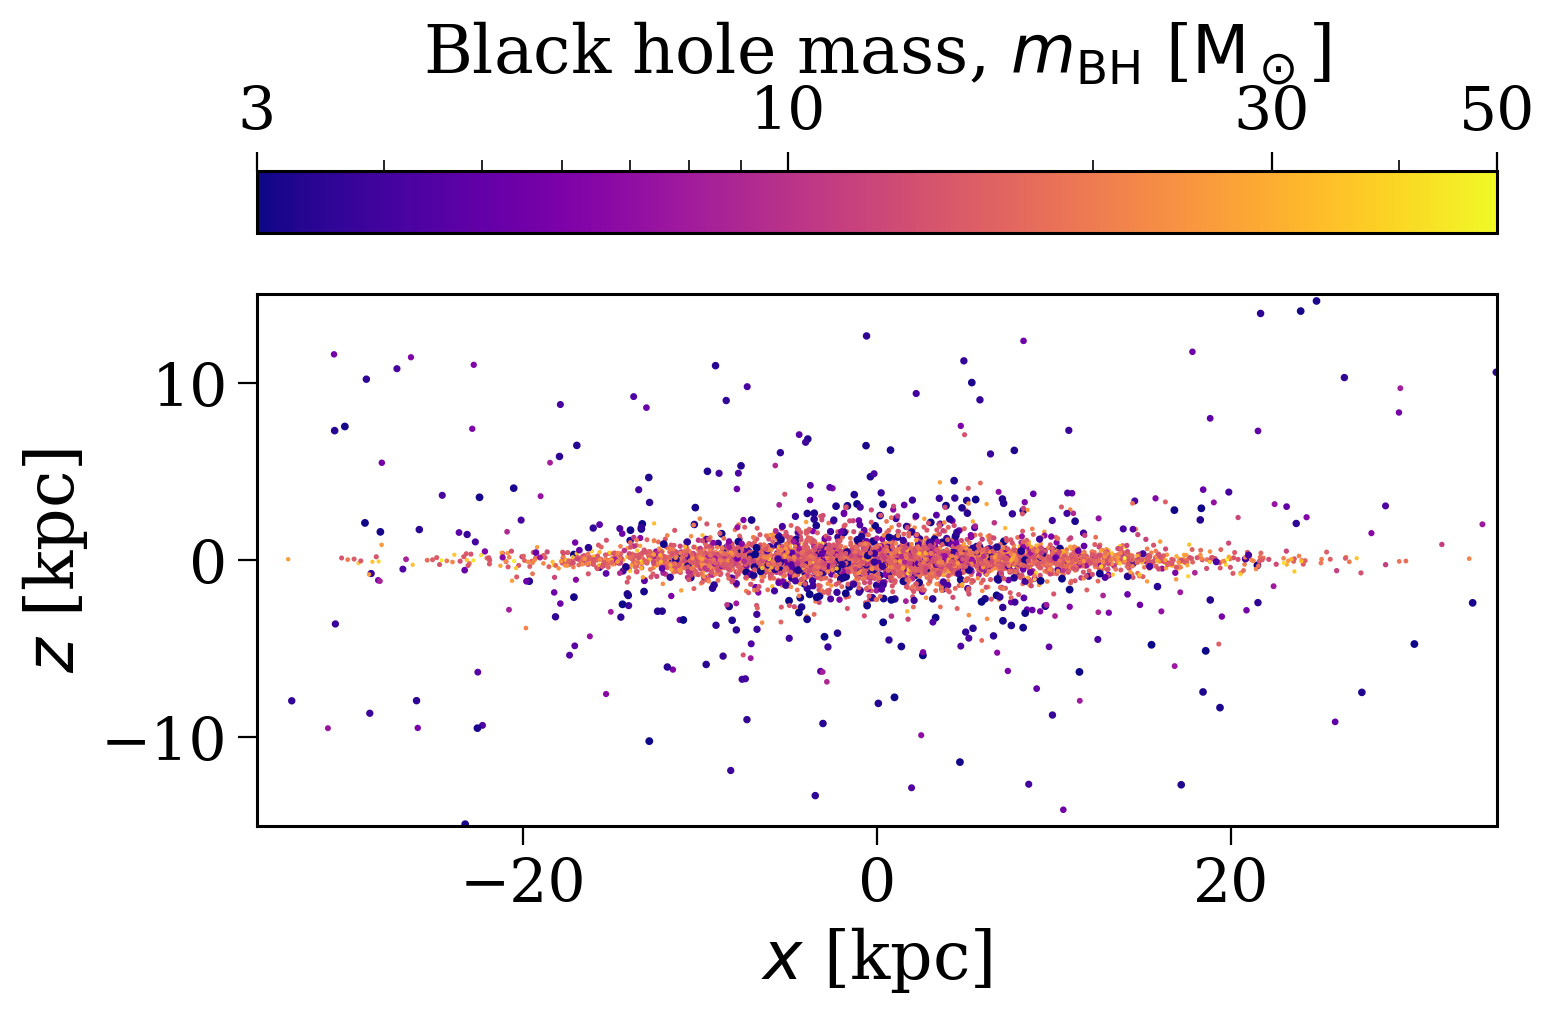

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# ax.scatter(data["Fiducial"]["pos"]["BH"][:, 0][bh_bh], data["Fiducial"]["pos"]["BH"][:, 2][bh_bh], s=1)
# ax.scatter(data["Fiducial"]["pos"]["BH"][:, 0][bh_ns], data["Fiducial"]["pos"]["BH"][:, 2][bh_ns], s=1)
scatter = ax.scatter(bh_star_pop.final_pos[:, 0], bh_star_pop.final_pos[:, 2], s=10 / bh_star_pop.final_bpp["mass_1"], c=bh_star_pop.final_bpp["mass_1"], cmap="plasma", norm=mpl.colors.LogNorm(vmin=3, vmax=50))
cbar = fig.colorbar(scatter, label=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]", format="%.0f", orientation="horizontal", location='top')
cbar.set_ticks([3, 10, 30, 50], labels=[3, 10, 30, 50])

ax.set(
    xlabel=r"$x$ [kpc]",
    ylabel="$z$ [kpc]",
    xlim=(-35, 35),
    ylim=(-15, 15),
    aspect='equal'
)

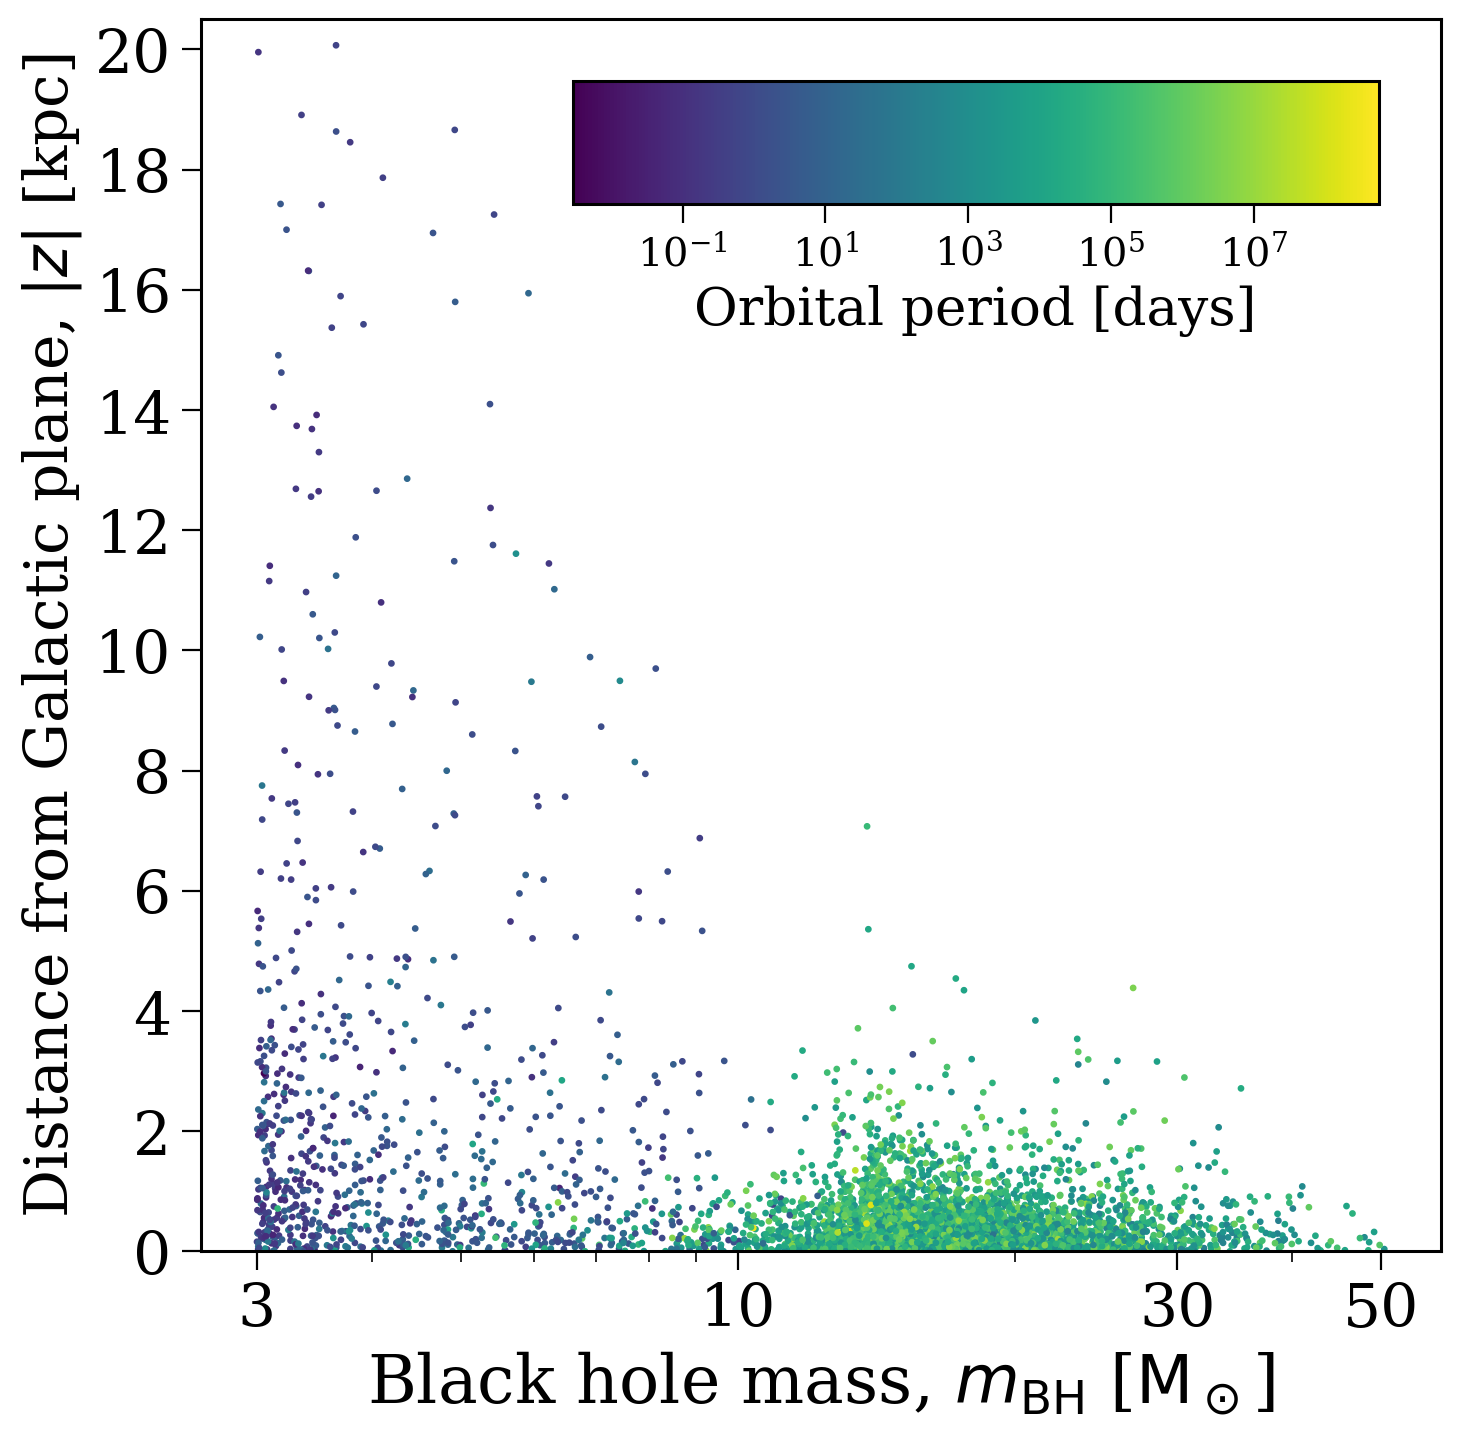

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    bh_star_pop.final_bpp["mass_1"], abs(bh_star_pop.final_pos[:, 2]), s=2, c=bh_star_pop.final_bpp["porb"],
    norm=mpl.colors.LogNorm(), rasterized=True
)

inset_ax = ax.inset_axes([0.3, 0.85, 0.65, 0.1])
cb = plt.colorbar(scatter, cax=inset_ax, label="Orbital period [days]", orientation="horizontal")
cb.set_label(cb.ax.get_xlabel(), fontsize=0.8*fs)
cb.ax.tick_params(labelsize=0.6*fs)

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Distance from Galactic plane, $|z|$ [kpc]",
    xscale="log",
    # yscale="log",
    ylim=(0, 20.5),
    xticks=[3, 10, 30, 50],
    xticklabels=[3, 10, 30, 50]
)
ax.set_ylabel(ax.get_ylabel(), fontsize=0.9*fs)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))

# plt.savefig("../plots/bh_binary_mbh_vs_z.pdf", bbox_inches='tight', format='pdf')

plt.show()

In [ ]:
bh_star_pop.processes = 32
bh_star_pop.store_entire_orbits = True
bh_star_pop.perform_galactic_evolution()

Integrating orbits:   9%|▊         | 443/5162 [00:00<00:06, 707.82it/s]

Integrating orbits: 100%|██████████| 5162/5162 [00:08<00:00, 579.99it/s]


In [ ]:
z_max = [np.abs(bh_star_pop.orbits[i].z).max().value for i in range(len(bh_star_pop.orbits))]

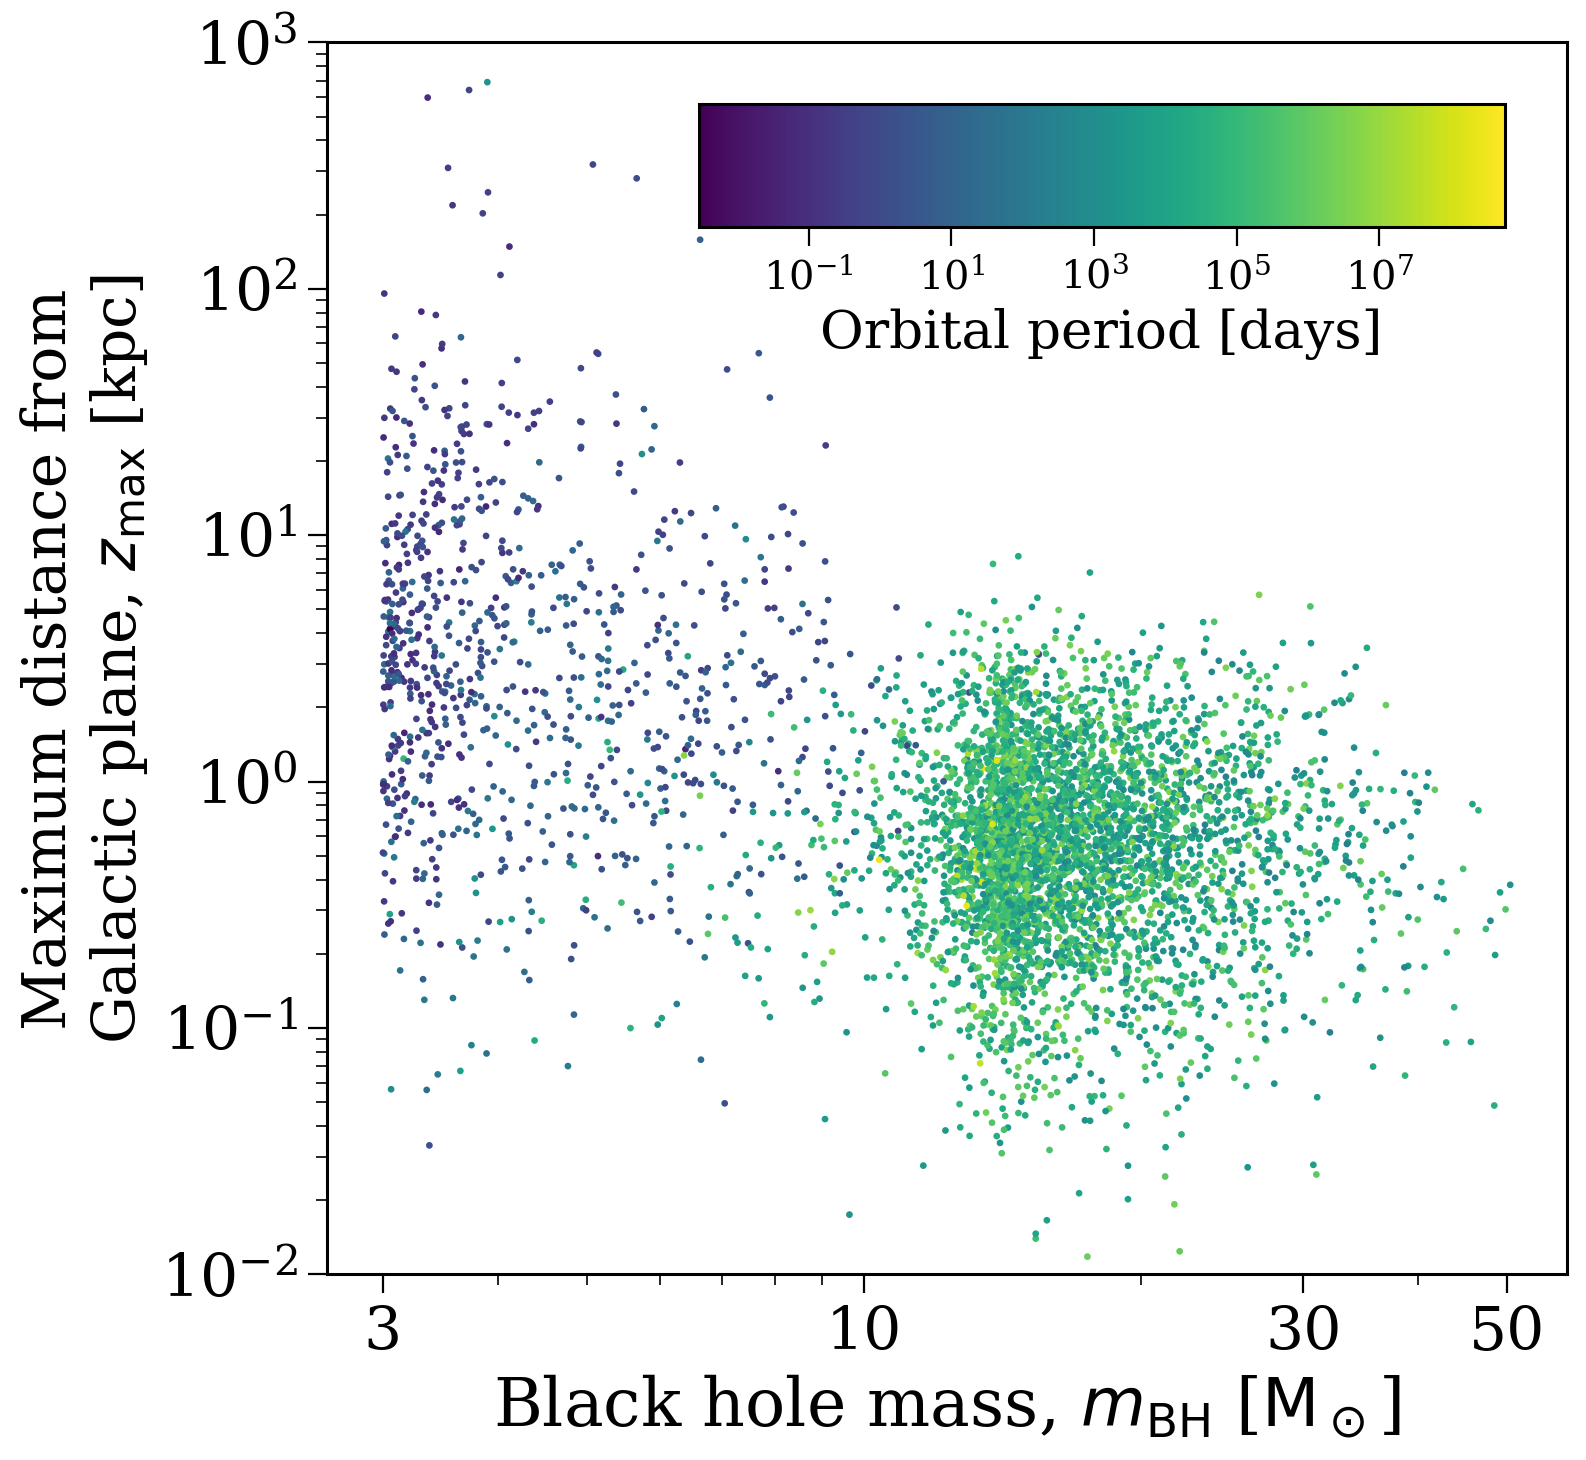

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    bh_star_pop.final_bpp["mass_1"], z_max, s=2, c=bh_star_pop.final_bpp["porb"],
    norm=mpl.colors.LogNorm(), rasterized=True
)

inset_ax = ax.inset_axes([0.3, 0.85, 0.65, 0.1])
cb = plt.colorbar(scatter, cax=inset_ax, label="Orbital period [days]", orientation="horizontal")
cb.set_label(cb.ax.get_xlabel(), fontsize=0.8*fs)
cb.ax.tick_params(labelsize=0.6*fs)

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Maximum distance from" + "\n" + r"Galactic plane, $z_{\rm max}$ [kpc]",
    xscale="log",
    yscale="log",
    ylim=(1e-2, 1e3),
    xticks=[3, 10, 30, 50],
    xticklabels=[3, 10, 30, 50]
)
ax.set_ylabel(ax.get_ylabel(), fontsize=0.9*fs)

plt.savefig("../plots/bh_binary_mbh_vs_zmax.pdf", bbox_inches='tight', format='pdf')

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


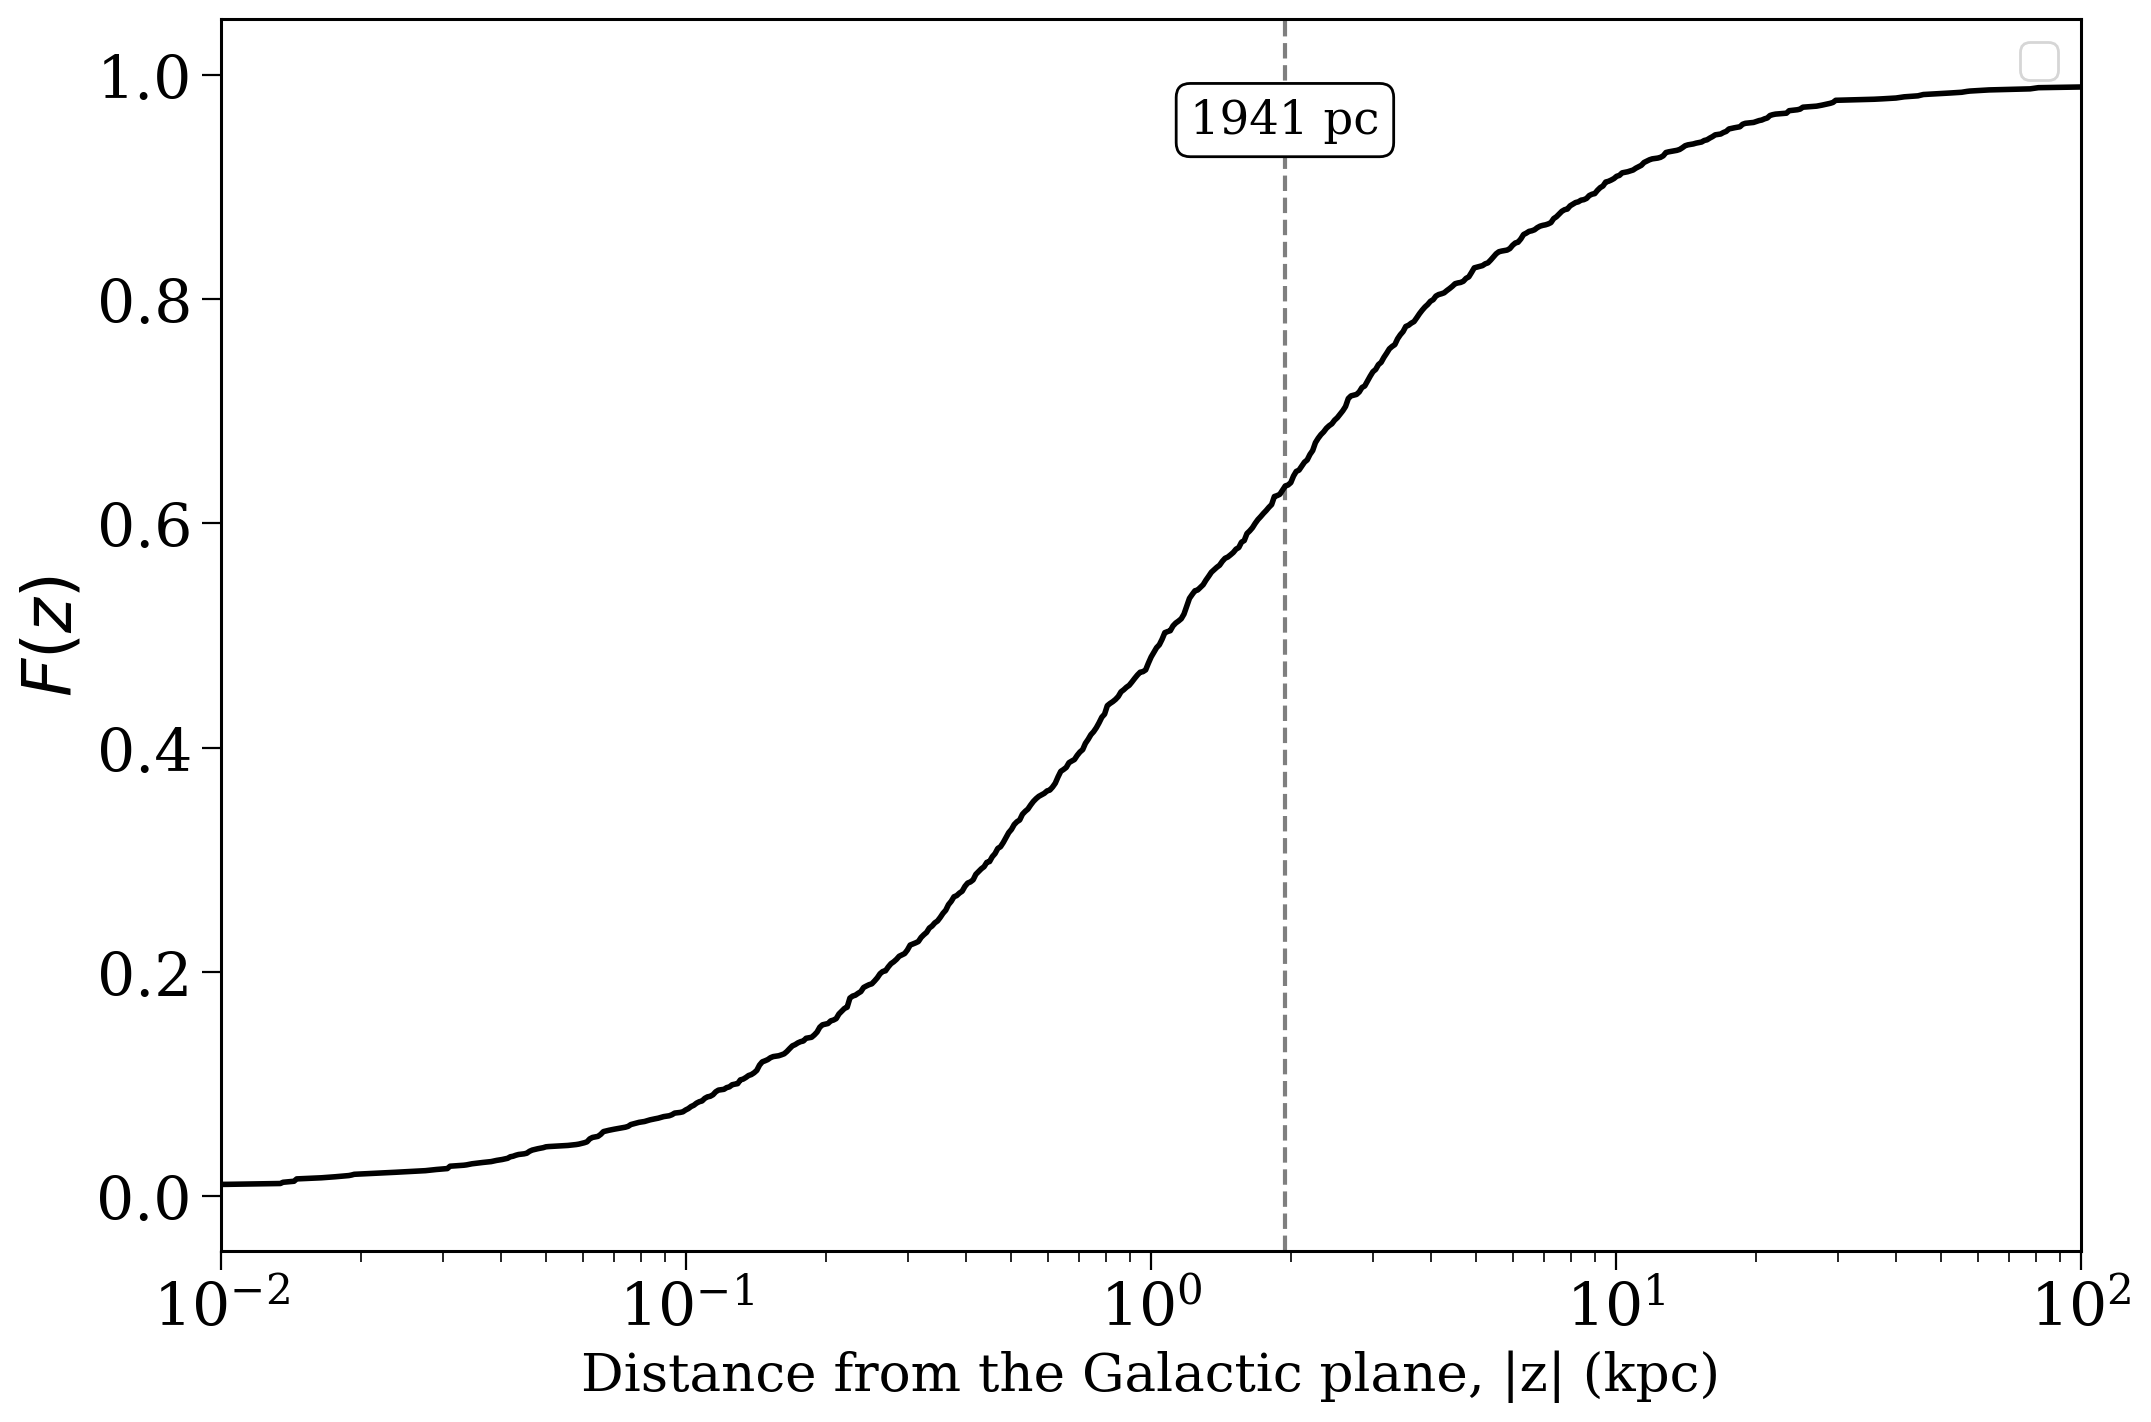

(np.float64(1.940611869239911),
 None,
 <Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Distance from the Galactic plane, |z| (kpc)', ylabel='$F(z)$'>)

In [ ]:
plotting.estimate_scale_height_cdf(
    bh_star_pop.final_pos[:, 2].value[bh_star_pop.final_bpp["mass_1"] < 10],
    xlim=(1e-2, 1e2),
    plot=True,
    scale_height_loc=0.98
)

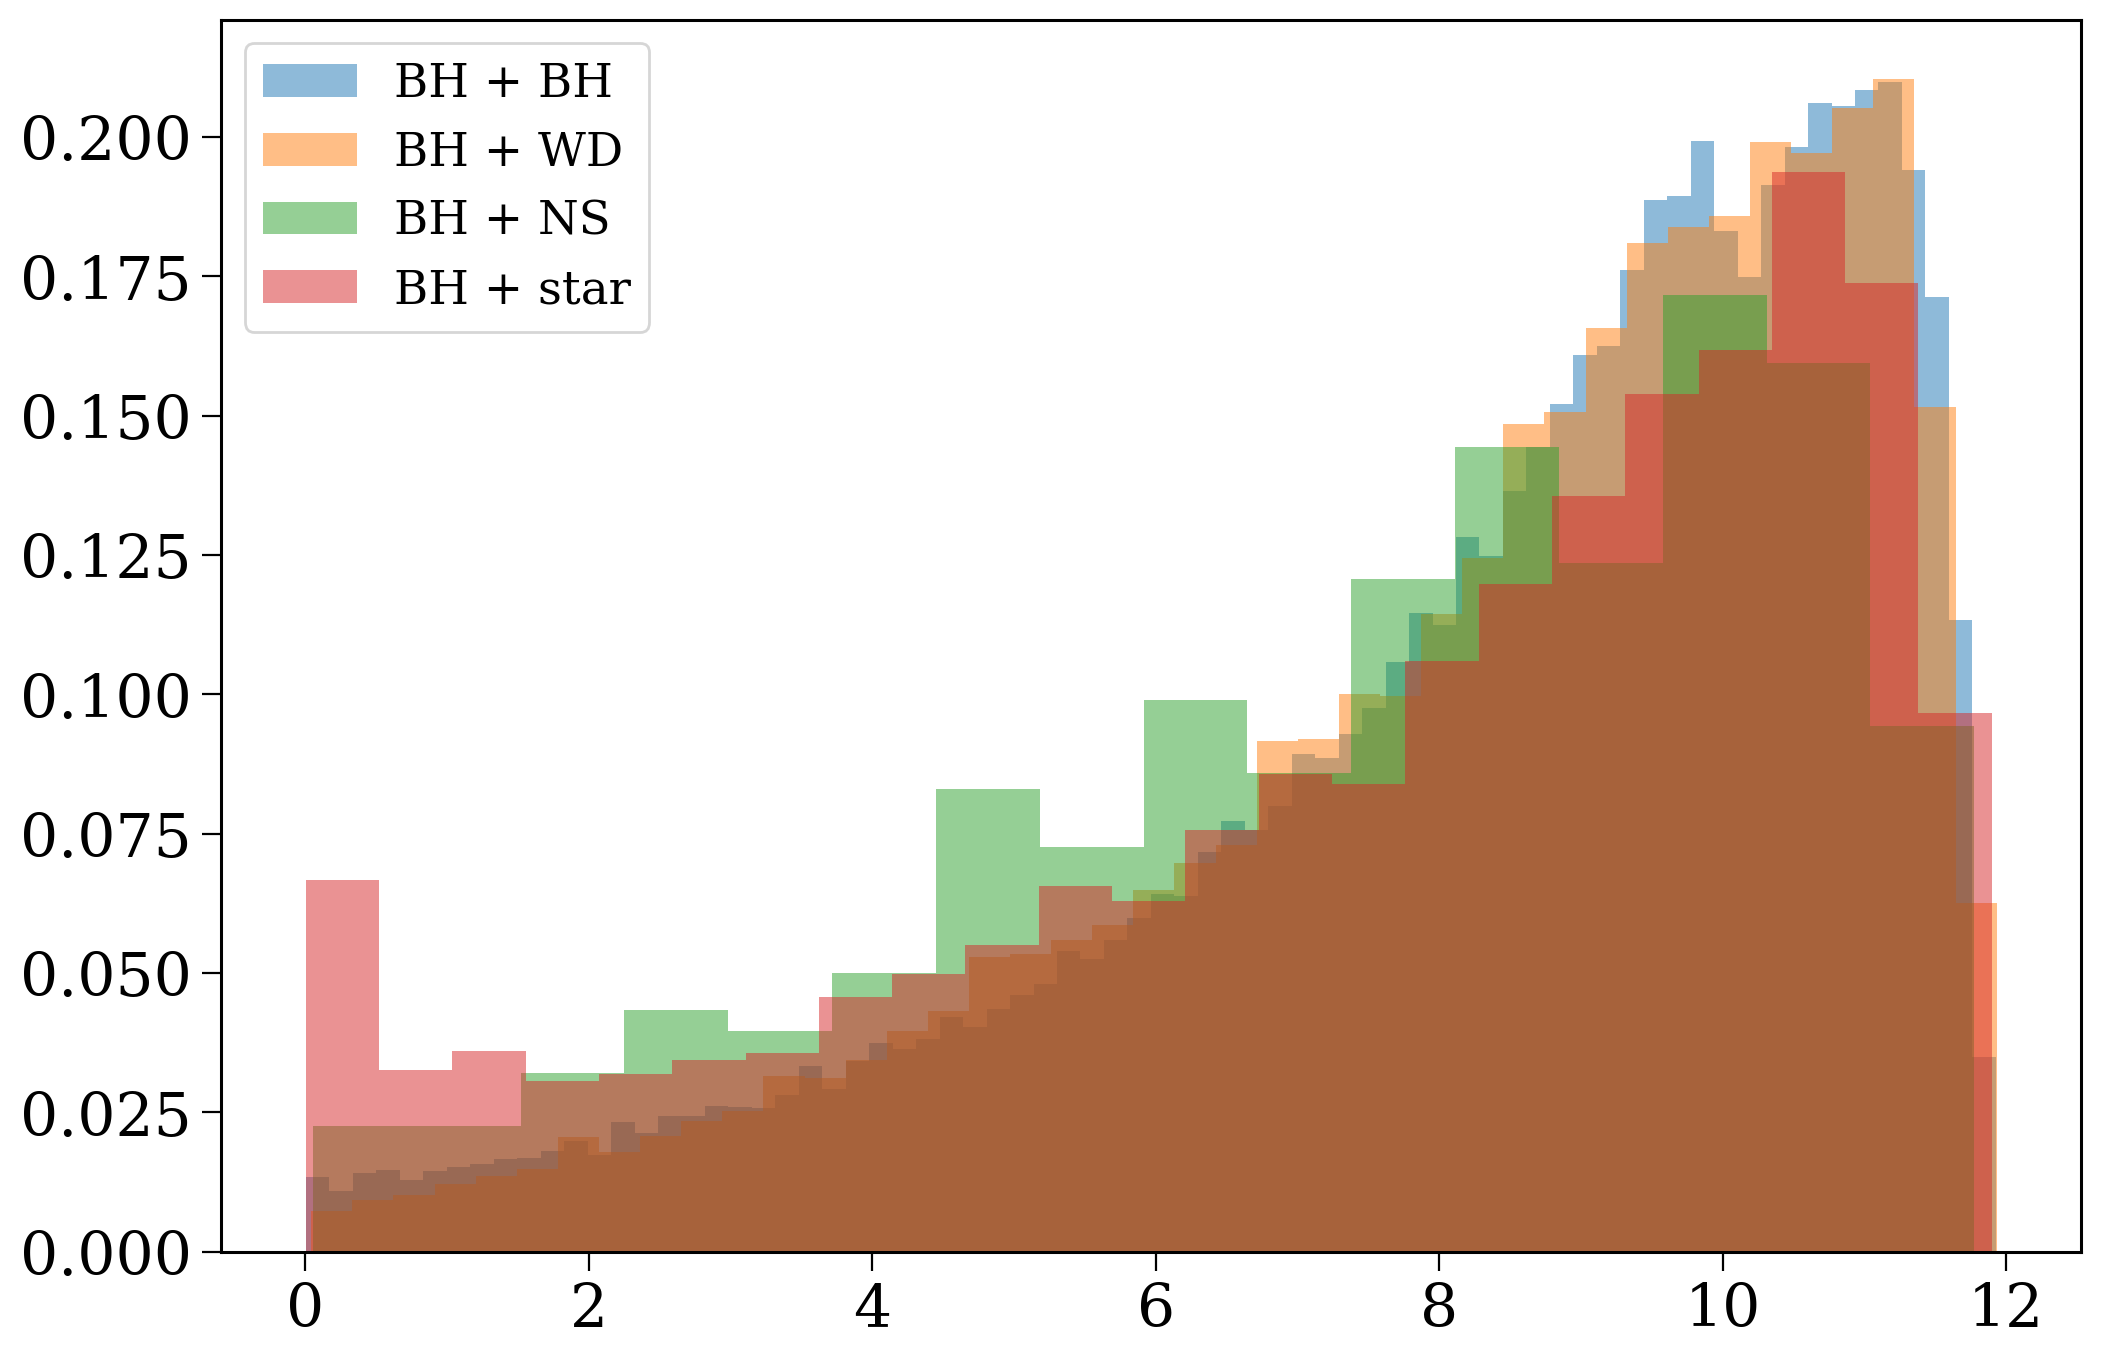

In [ ]:
plt.hist(data["Fiducial"]["tau"]["BH"][bh_bh], bins="auto", alpha=0.5, density=True, label="BH + BH");
plt.hist(data["Fiducial"]["tau"]["BH"][bh_wd], bins="auto", alpha=0.5, density=True, label="BH + WD");
plt.hist(data["Fiducial"]["tau"]["BH"][bh_ns], bins="auto", alpha=0.5, density=True, label="BH + NS");
plt.hist(bh_star_pop.initial_galaxy.tau, bins="auto", alpha=0.5, density=True, label="BH + star")
plt.legend()
plt.show()

In [ ]:
bh_star_pop.final_bpp["mass_2"]

6311        1.268522
13374       1.817678
15102       0.121333
25048       0.244668
29747       1.637282
              ...   
31487414    0.133893
31496533    0.532118
31501311    0.364887
31513418    0.745483
31517028    0.088505
Name: mass_2, Length: 5162, dtype: float64

In [ ]:
len(bh_star_pop)

5162

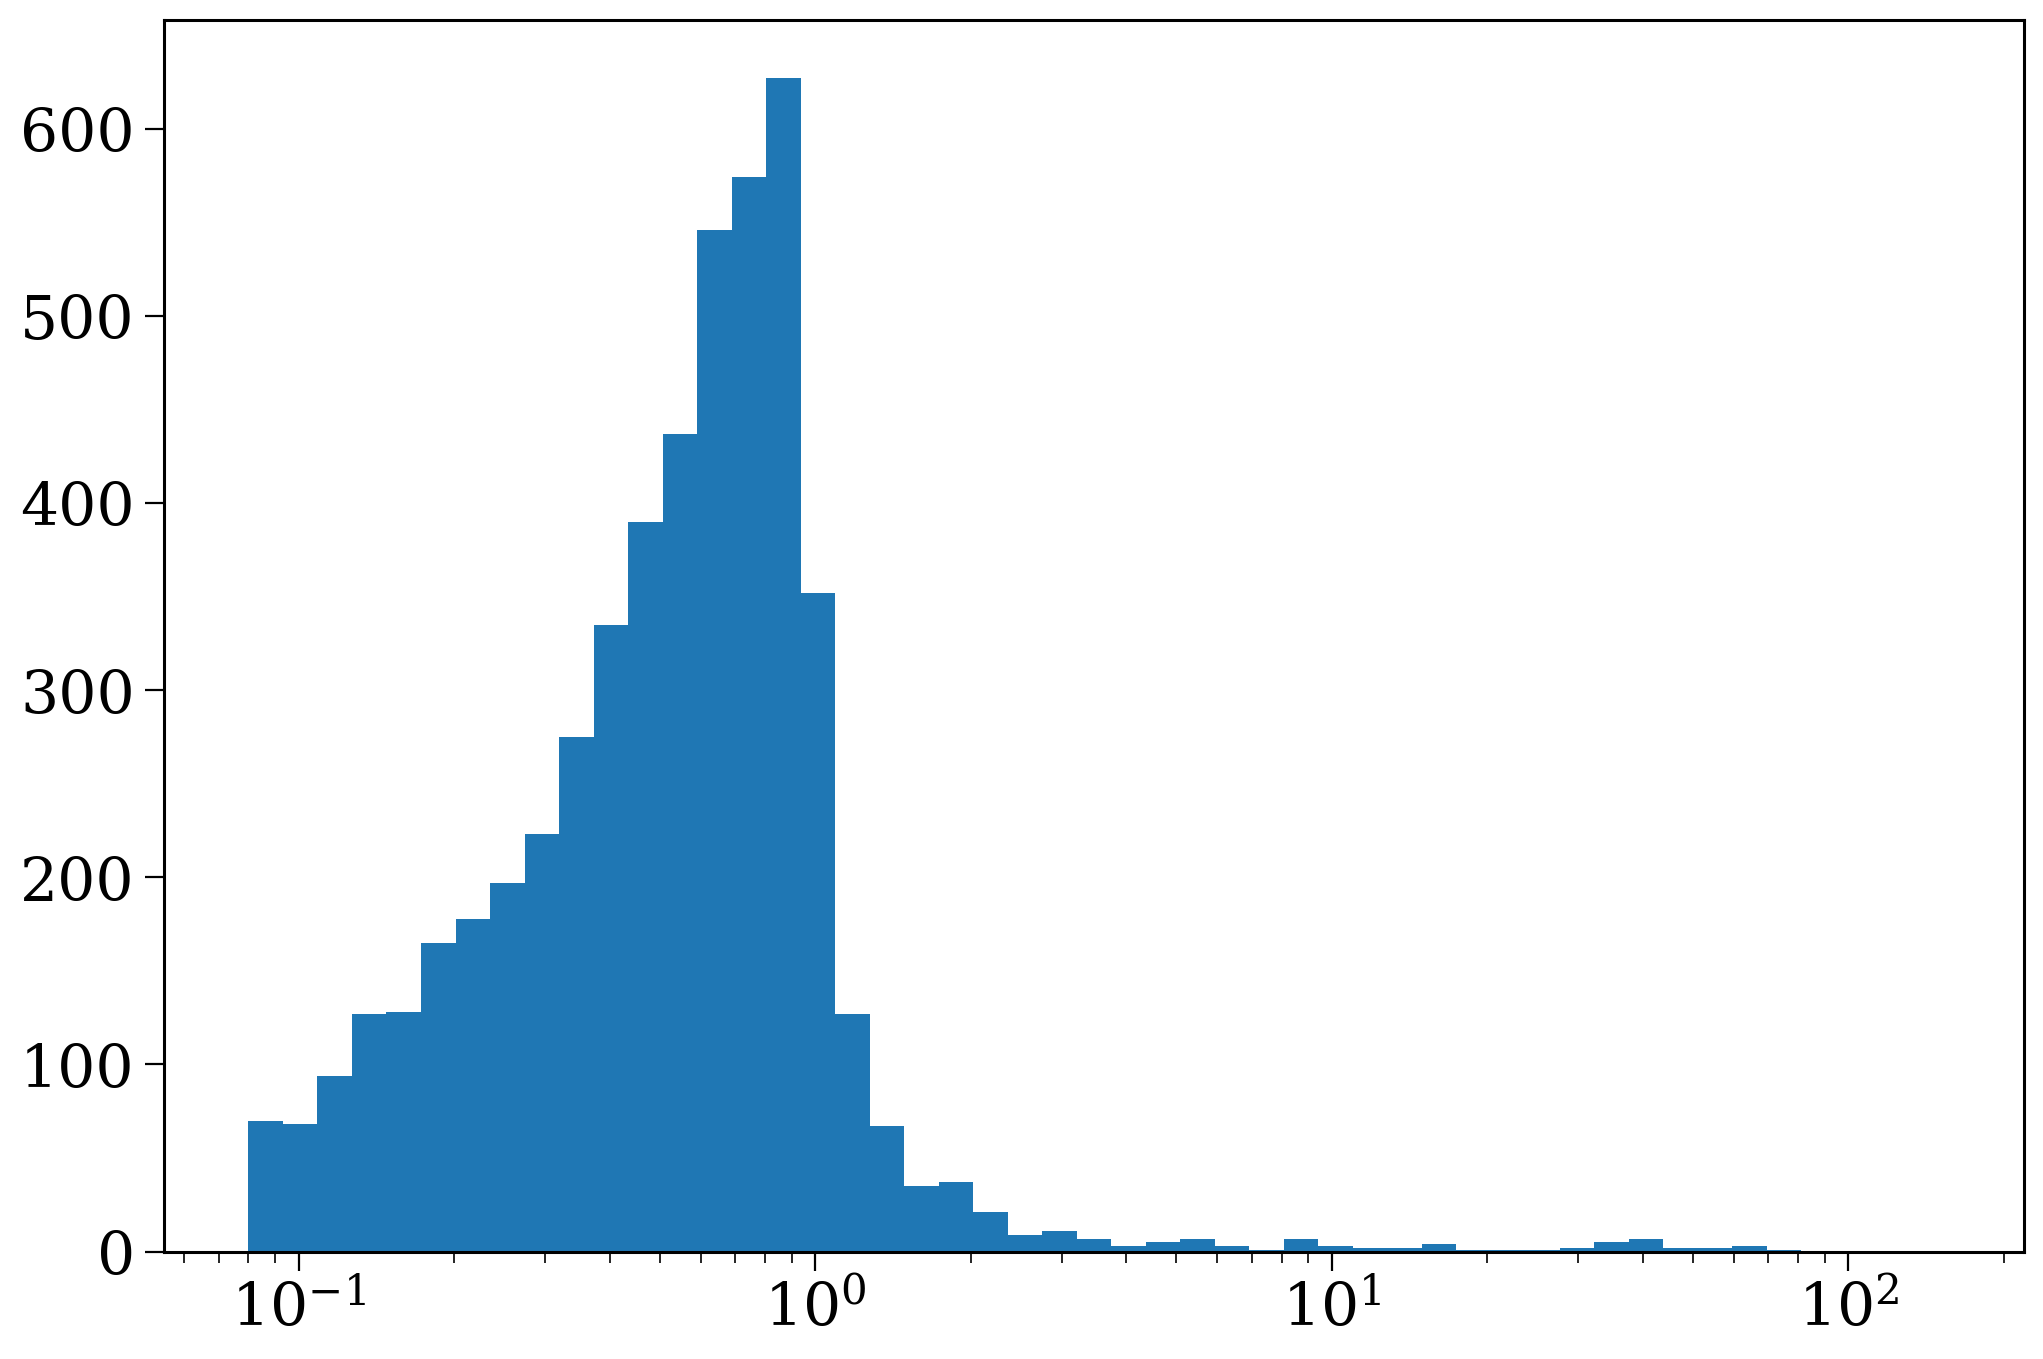

In [ ]:
plt.hist(bh_star_pop.final_bpp["mass_2"], bins=np.geomspace(0.08, 150, 50));
plt.xscale("log")

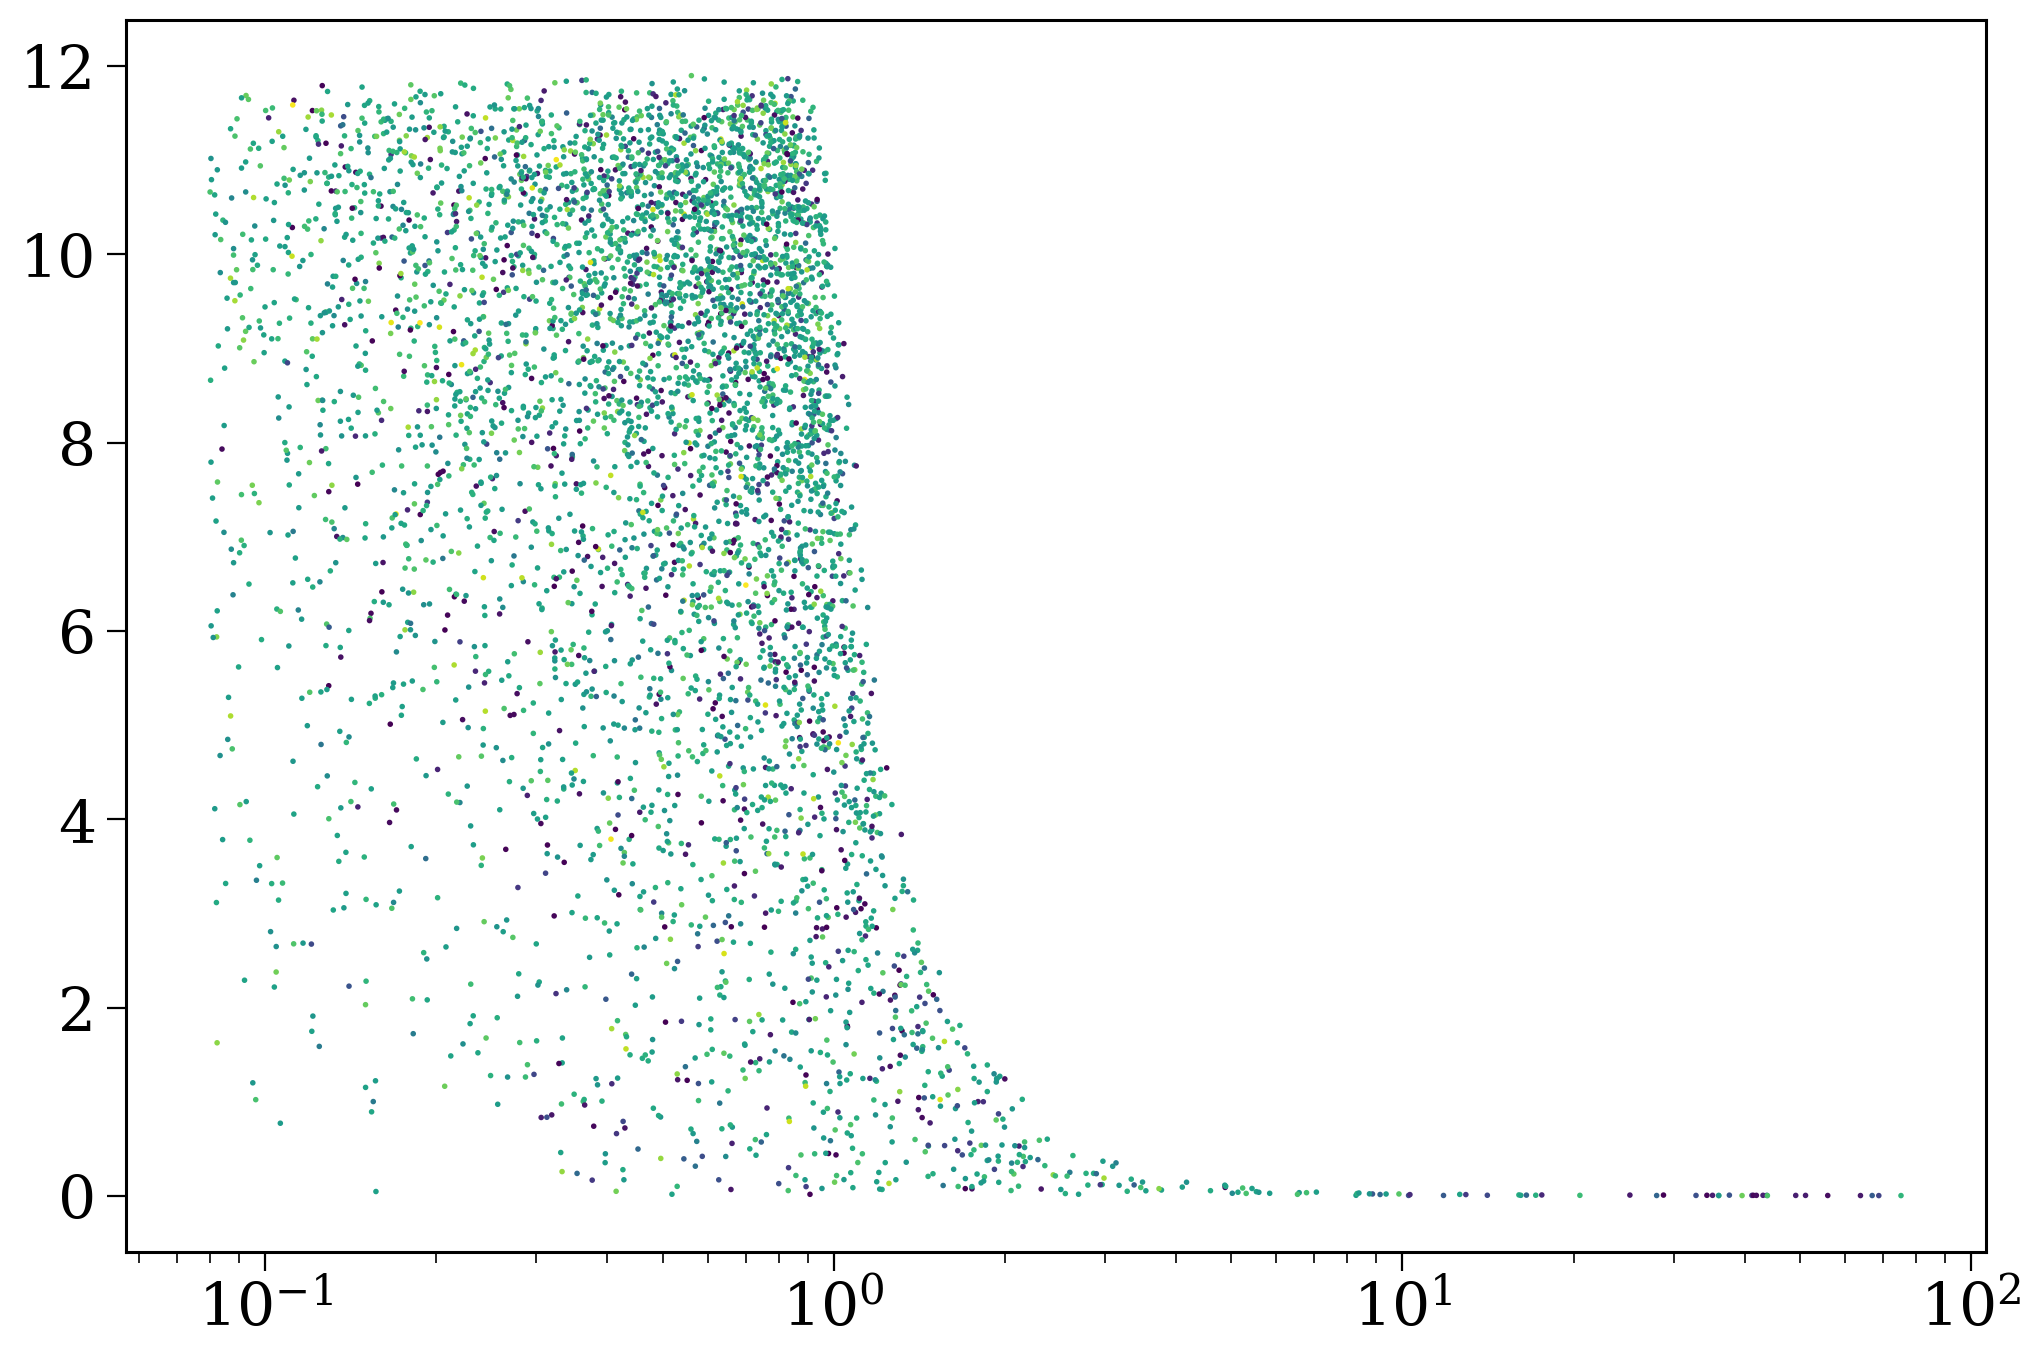

In [ ]:
plt.scatter(bh_star_pop.final_bpp["mass_2"], bh_star_pop.initial_galaxy.tau, c=np.log10(bh_star_pop.final_bpp["mass_1"]), s=1)
plt.xscale("log")


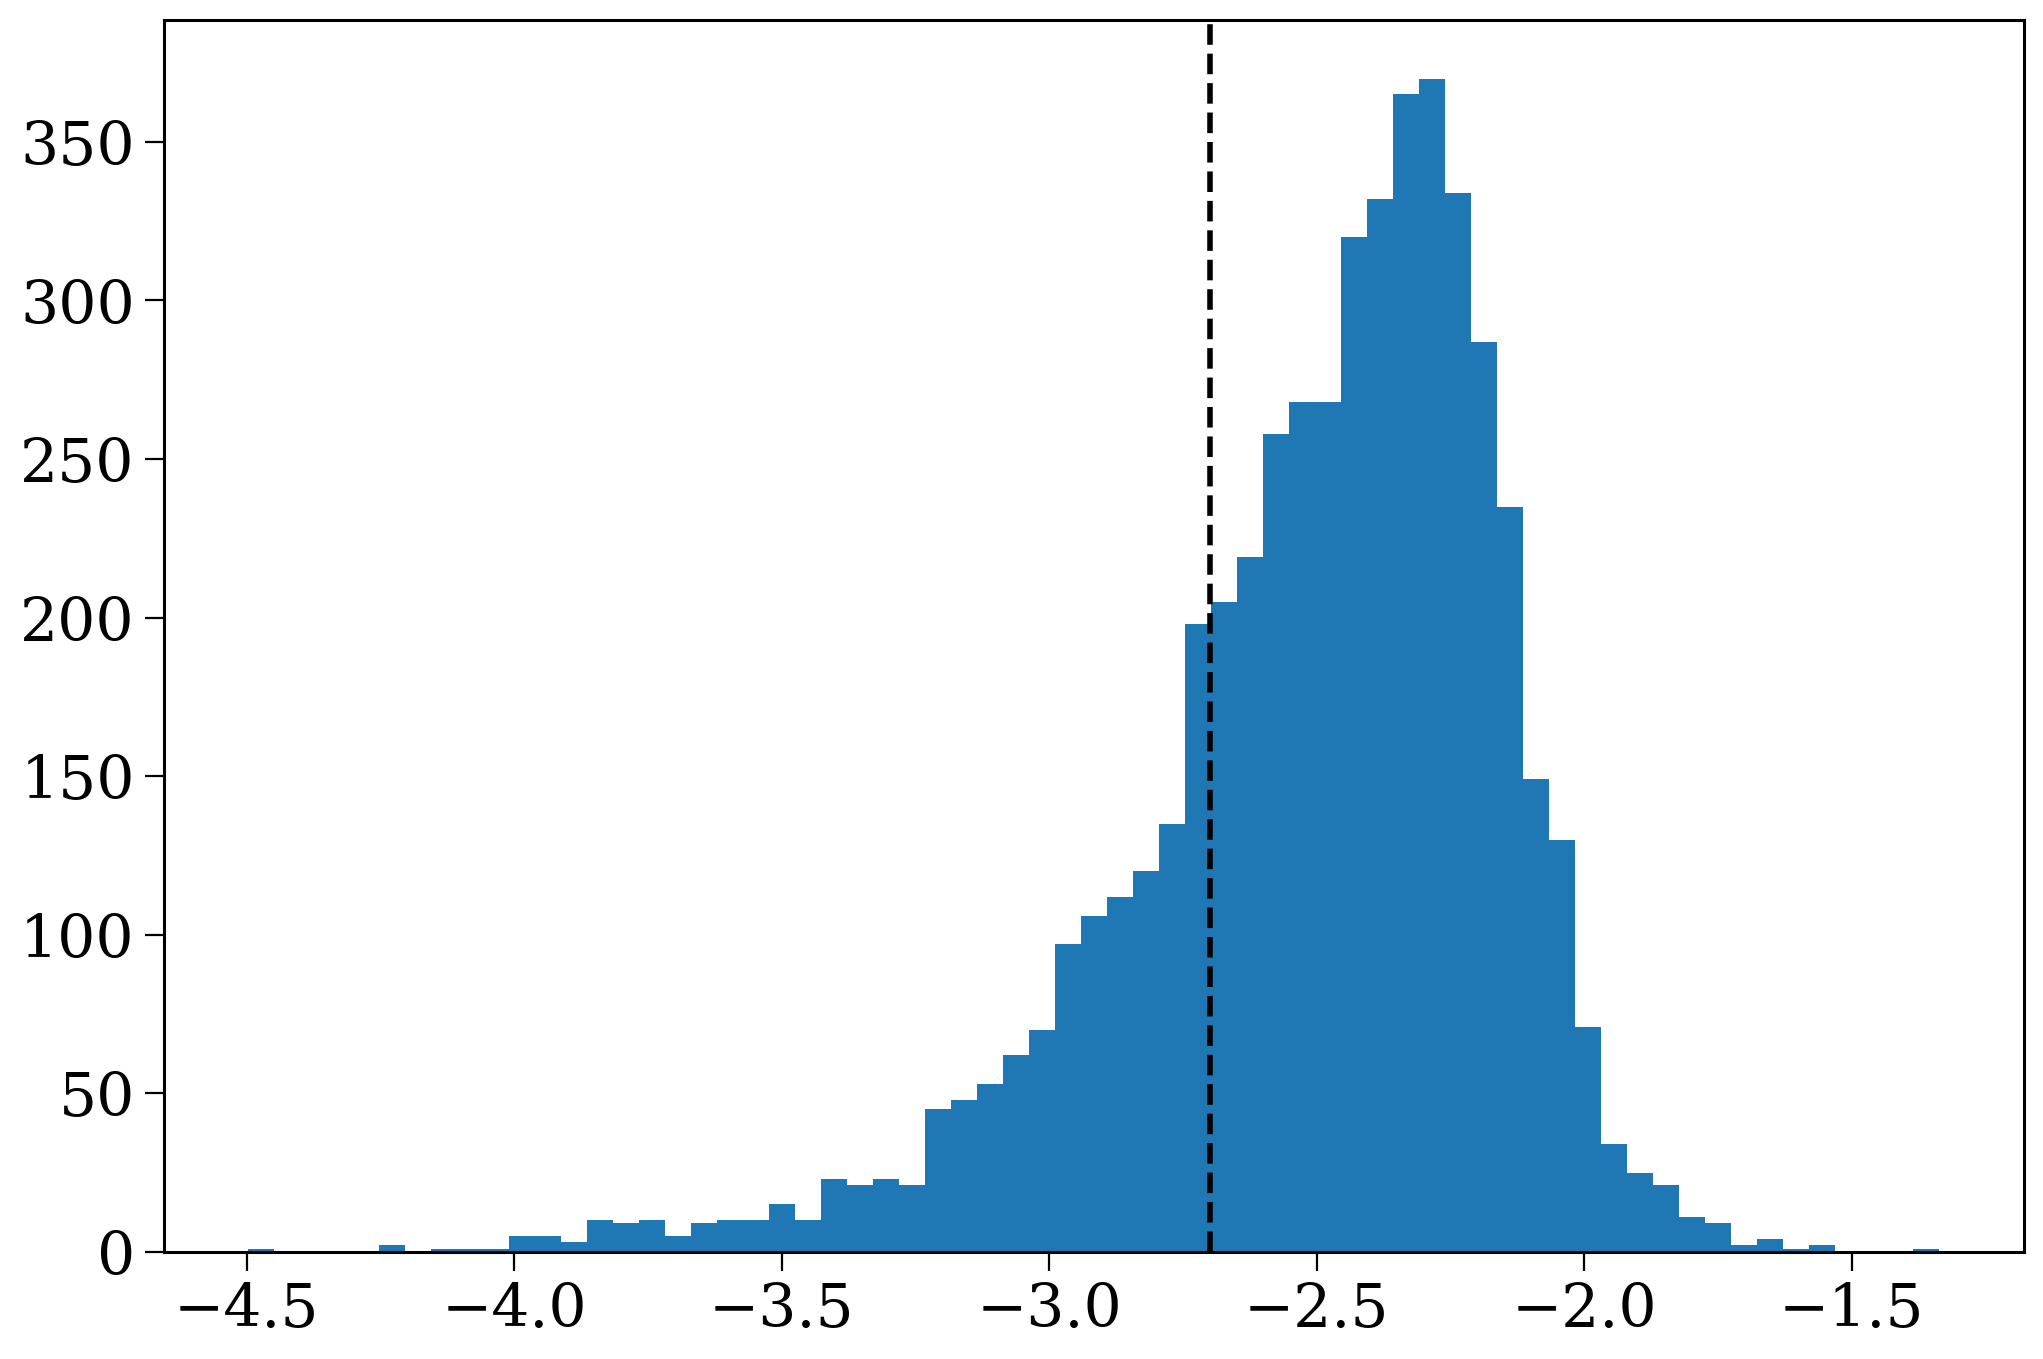

In [ ]:
plt.hist(np.log10(bh_star_pop.initial_galaxy.Z), bins="auto");
plt.axvline(np.log10(0.002), ls='--', c='k', lw=2)

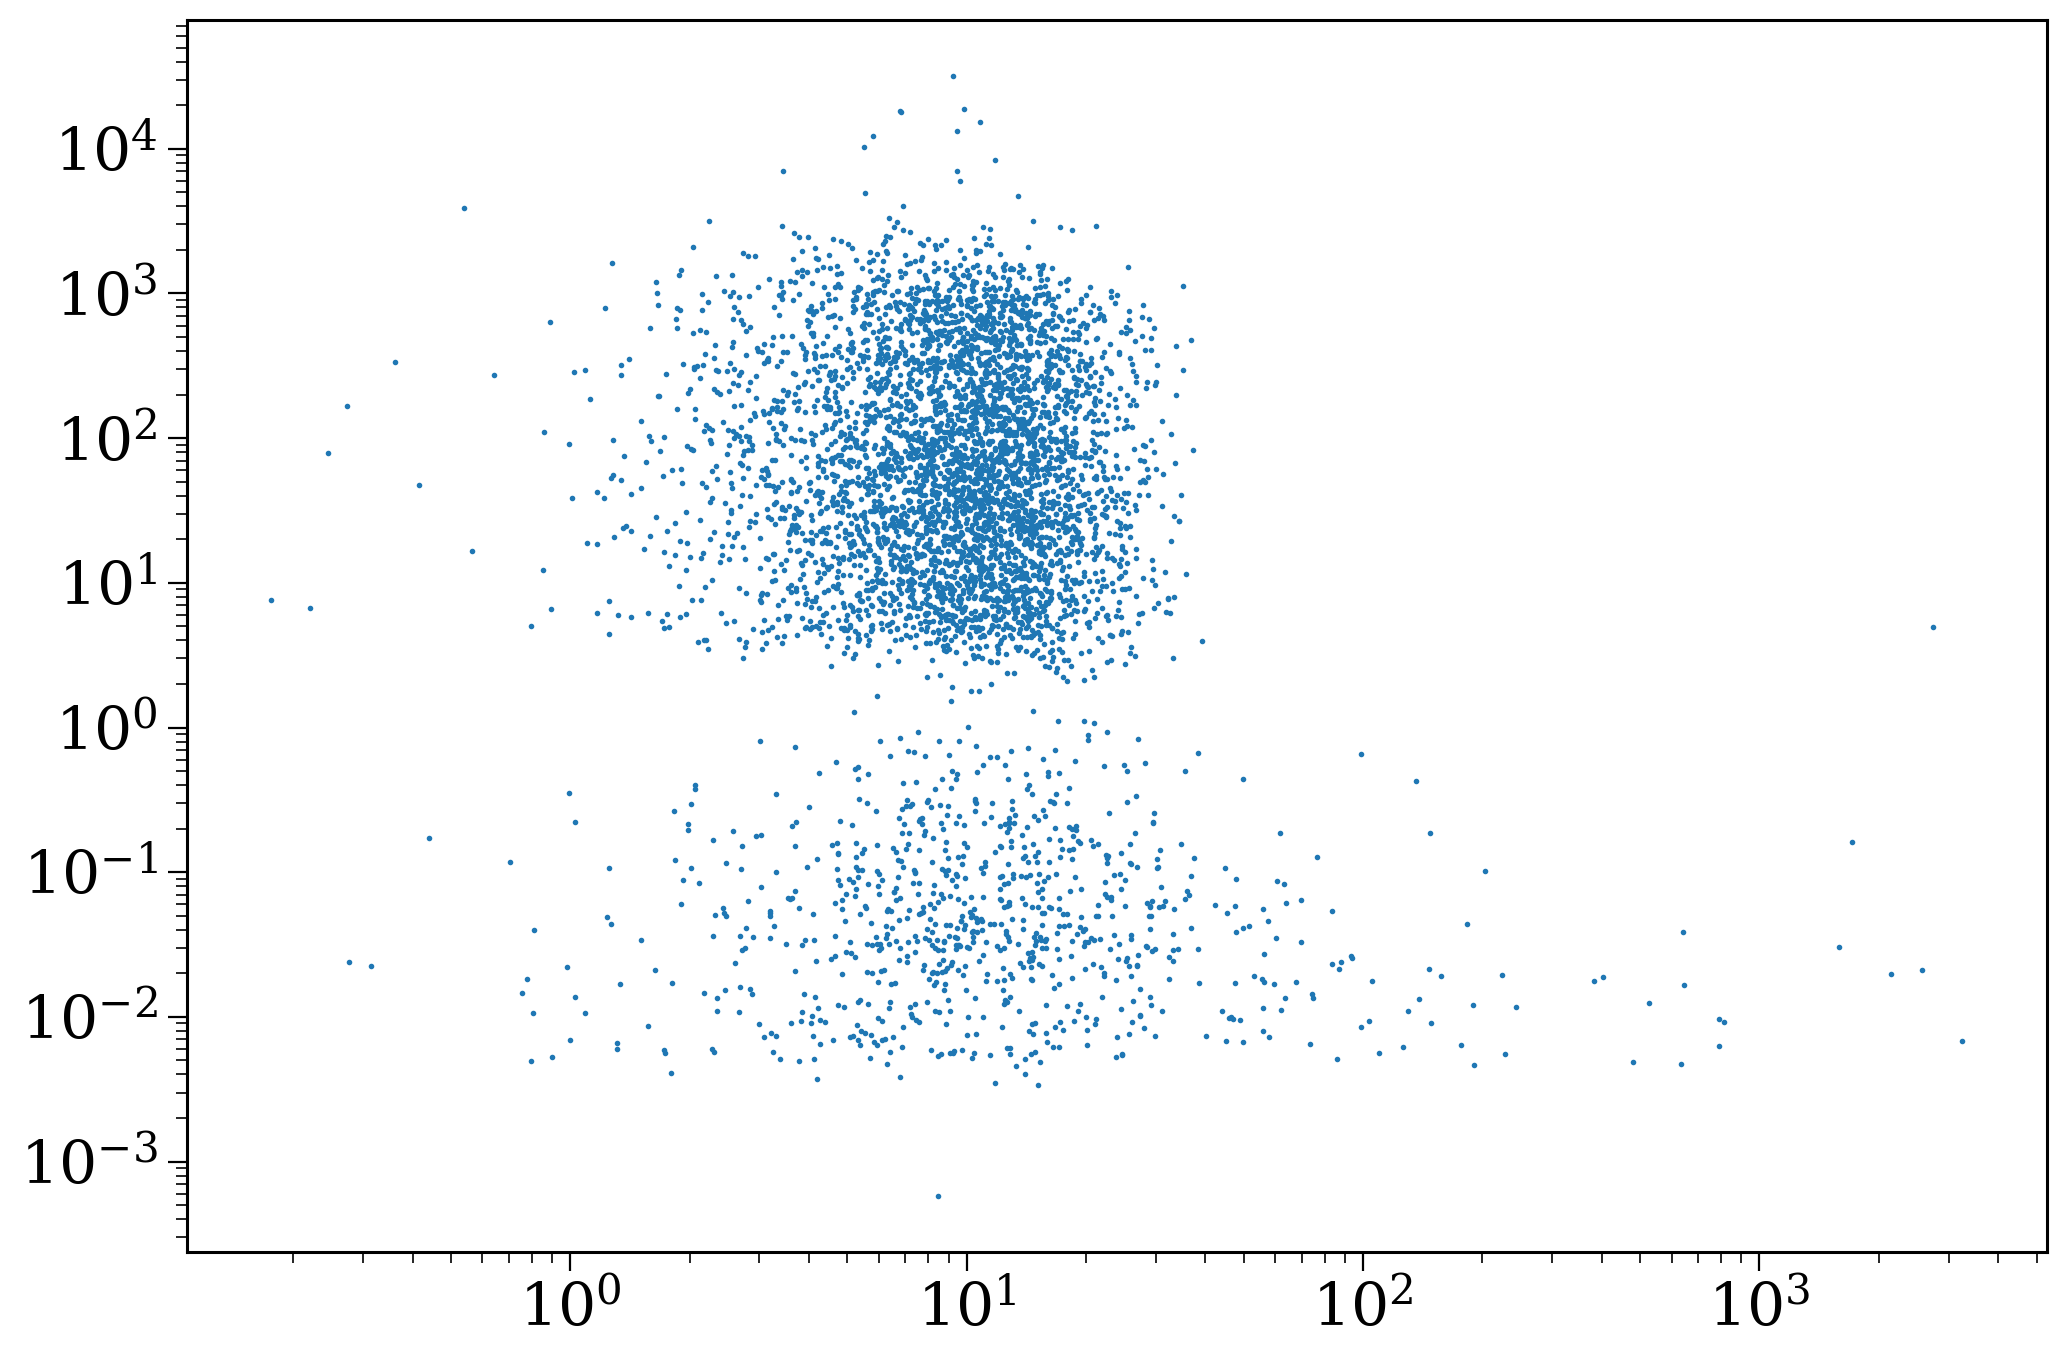

In [ ]:
import astropy.units as u
plt.scatter(
    np.linalg.norm(bh_star_pop.final_pos[:, :2], axis=1),
    (bh_star_pop.final_bpp["sep"].values * u.Rsun).to(u.AU),
    s=1 
)
plt.yscale("log")
plt.xscale("log")

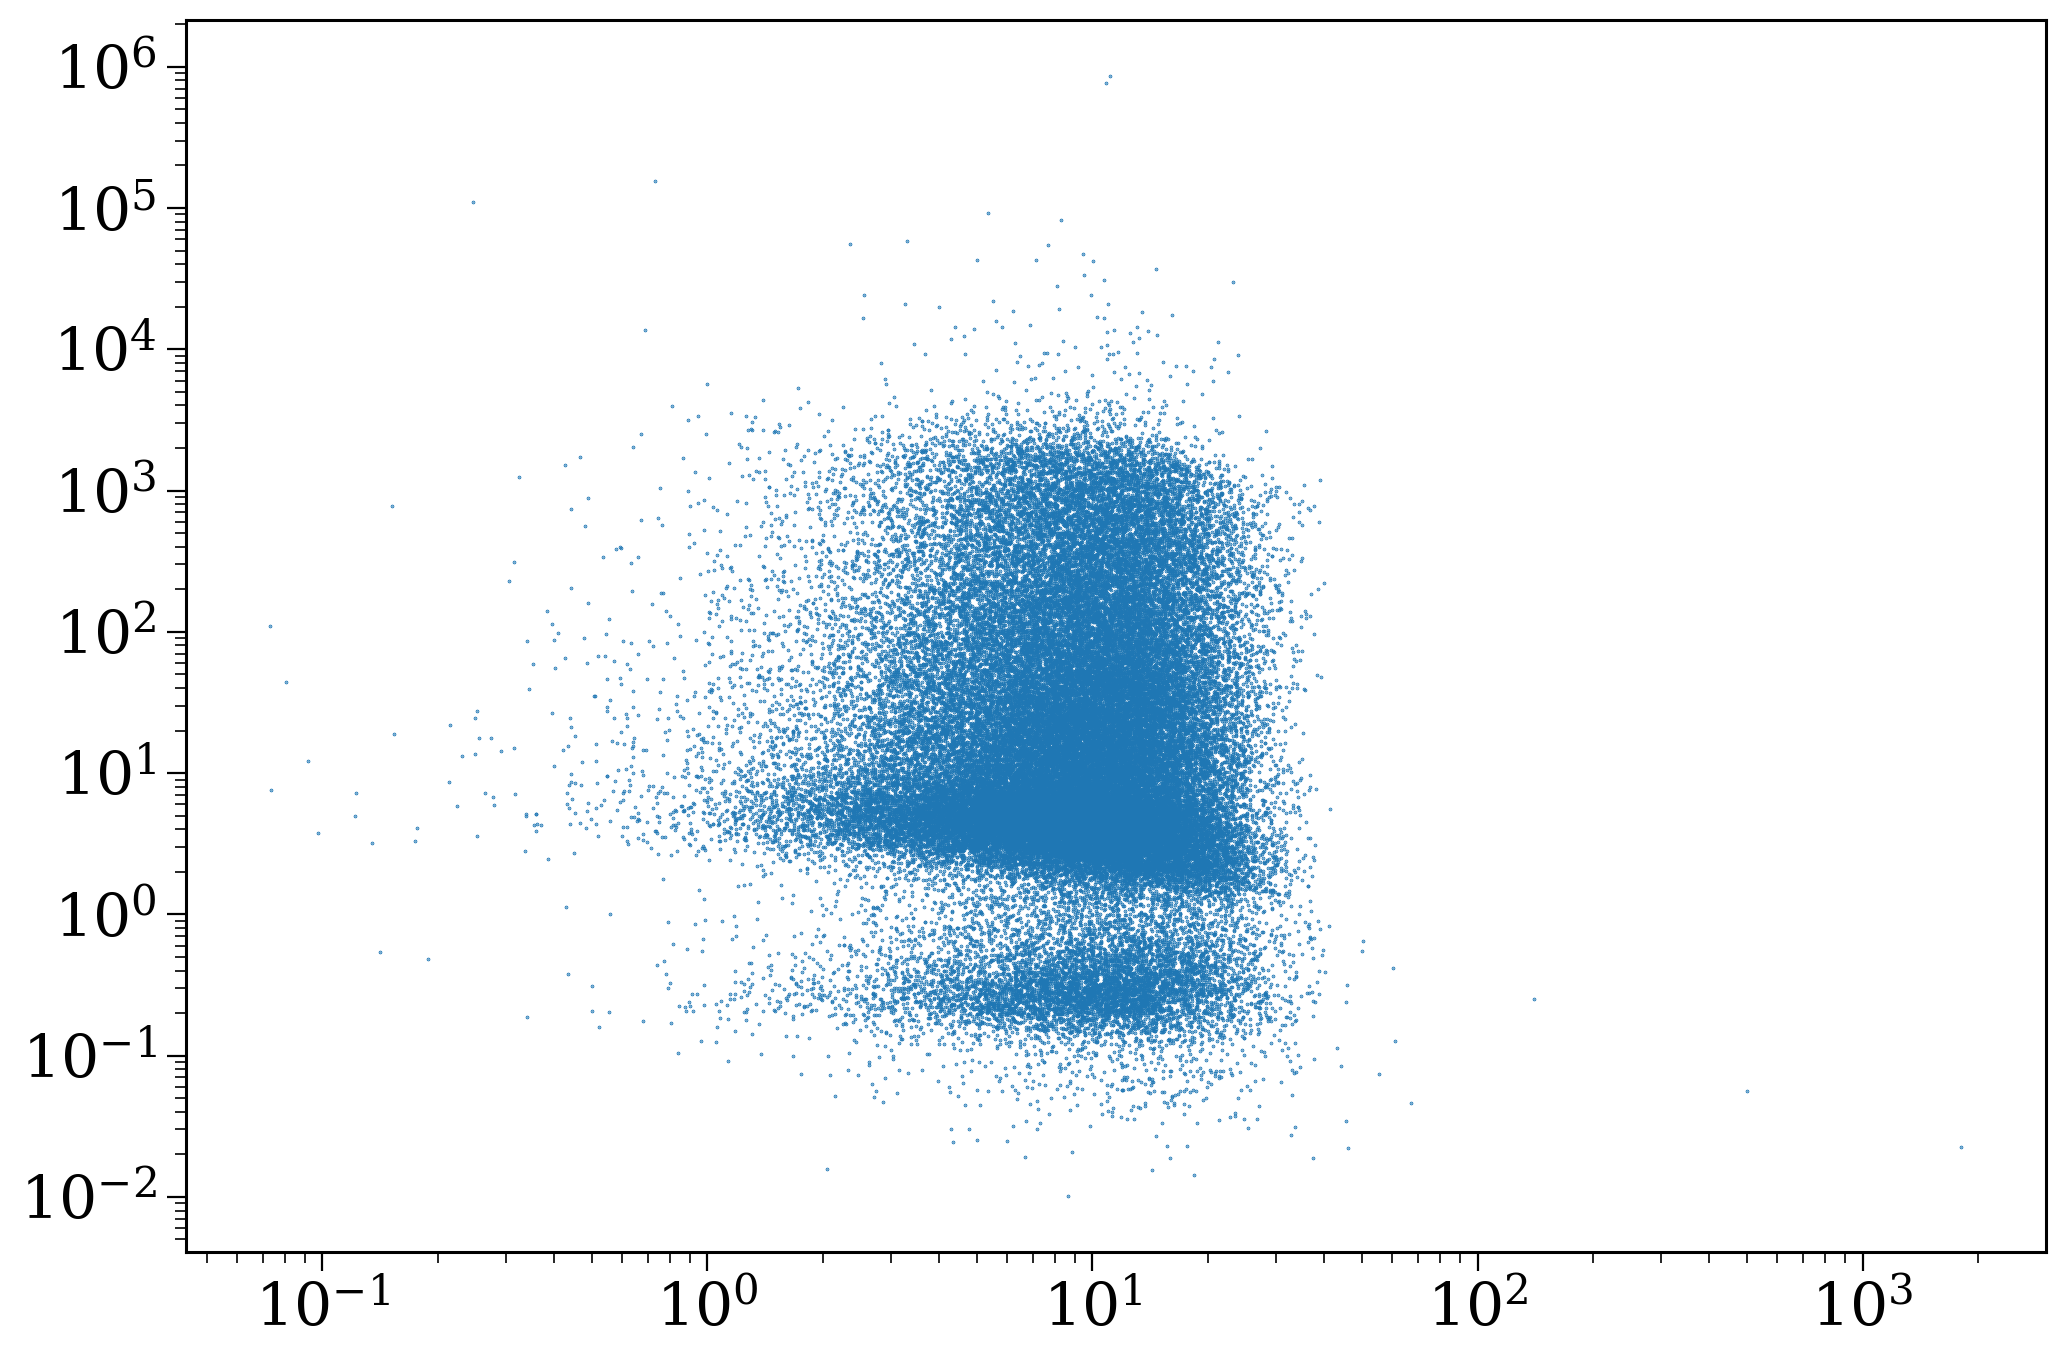

In [ ]:
scatter = plt.scatter(np.linalg.norm(data["Fiducial"]["pos"]["BH"][bh_bh][:, :2], axis=1), (data["Fiducial"]["sep"]["BH"][bh_bh] * u.Rsun).to(u.AU), s=0.1)
plt.xscale("log")
plt.yscale("log")

In [ ]:
pos = bh_star_pop.final_pos.to(u.kpc).value
scale_up = 6e10 / bh_star_pop.mass_binaries

R = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2)
z = pos[:, 2]

R_major = 8
R_minor = 0.5

near_sun = (R >= R_major - R_minor) & (R < R_major + R_minor) & (np.abs(z) < R_minor) #& (bh_star_pop.final_bpp["mass_1"] < 14)
print(near_sun.sum())
torus_volume = (2 * np.pi * R_major * (np.pi * R_minor**2)) * u.kpc**3

density = (near_sun.sum() / torus_volume * scale_up).to(u.pc**-3)
print(f"Local density: {density:1.1e}")
print(f"The nearest BH+star is expected to be {((1 / density.to(u.pc**(-3)))**(1/3)).to(u.pc):.1f} away")

237
Local density: 2.0e-07 1 / pc3
The nearest BH+star is expected to be 172.2 pc away


In [ ]:
bh_star_pop.final_bpp["RRLO_2"]

6311        0.139156
13374       0.001309
15102       0.000118
25048       0.000144
29747       0.000536
              ...   
31487414    0.002240
31496533    0.000952
31501311    0.002187
31513418    0.327813
31517028    0.000158
Name: RRLO_2, Length: 5162, dtype: float64

# Possible XRBs

In [ ]:
f"Fraction of BHs with Roche lobe overflow: {((bh_star_pop.final_bpp['RRLO_2'] > 1.0).sum() / len(bh_star_pop)):.2f}"

'Fraction of BHs with Roche lobe overflow: 0.07'

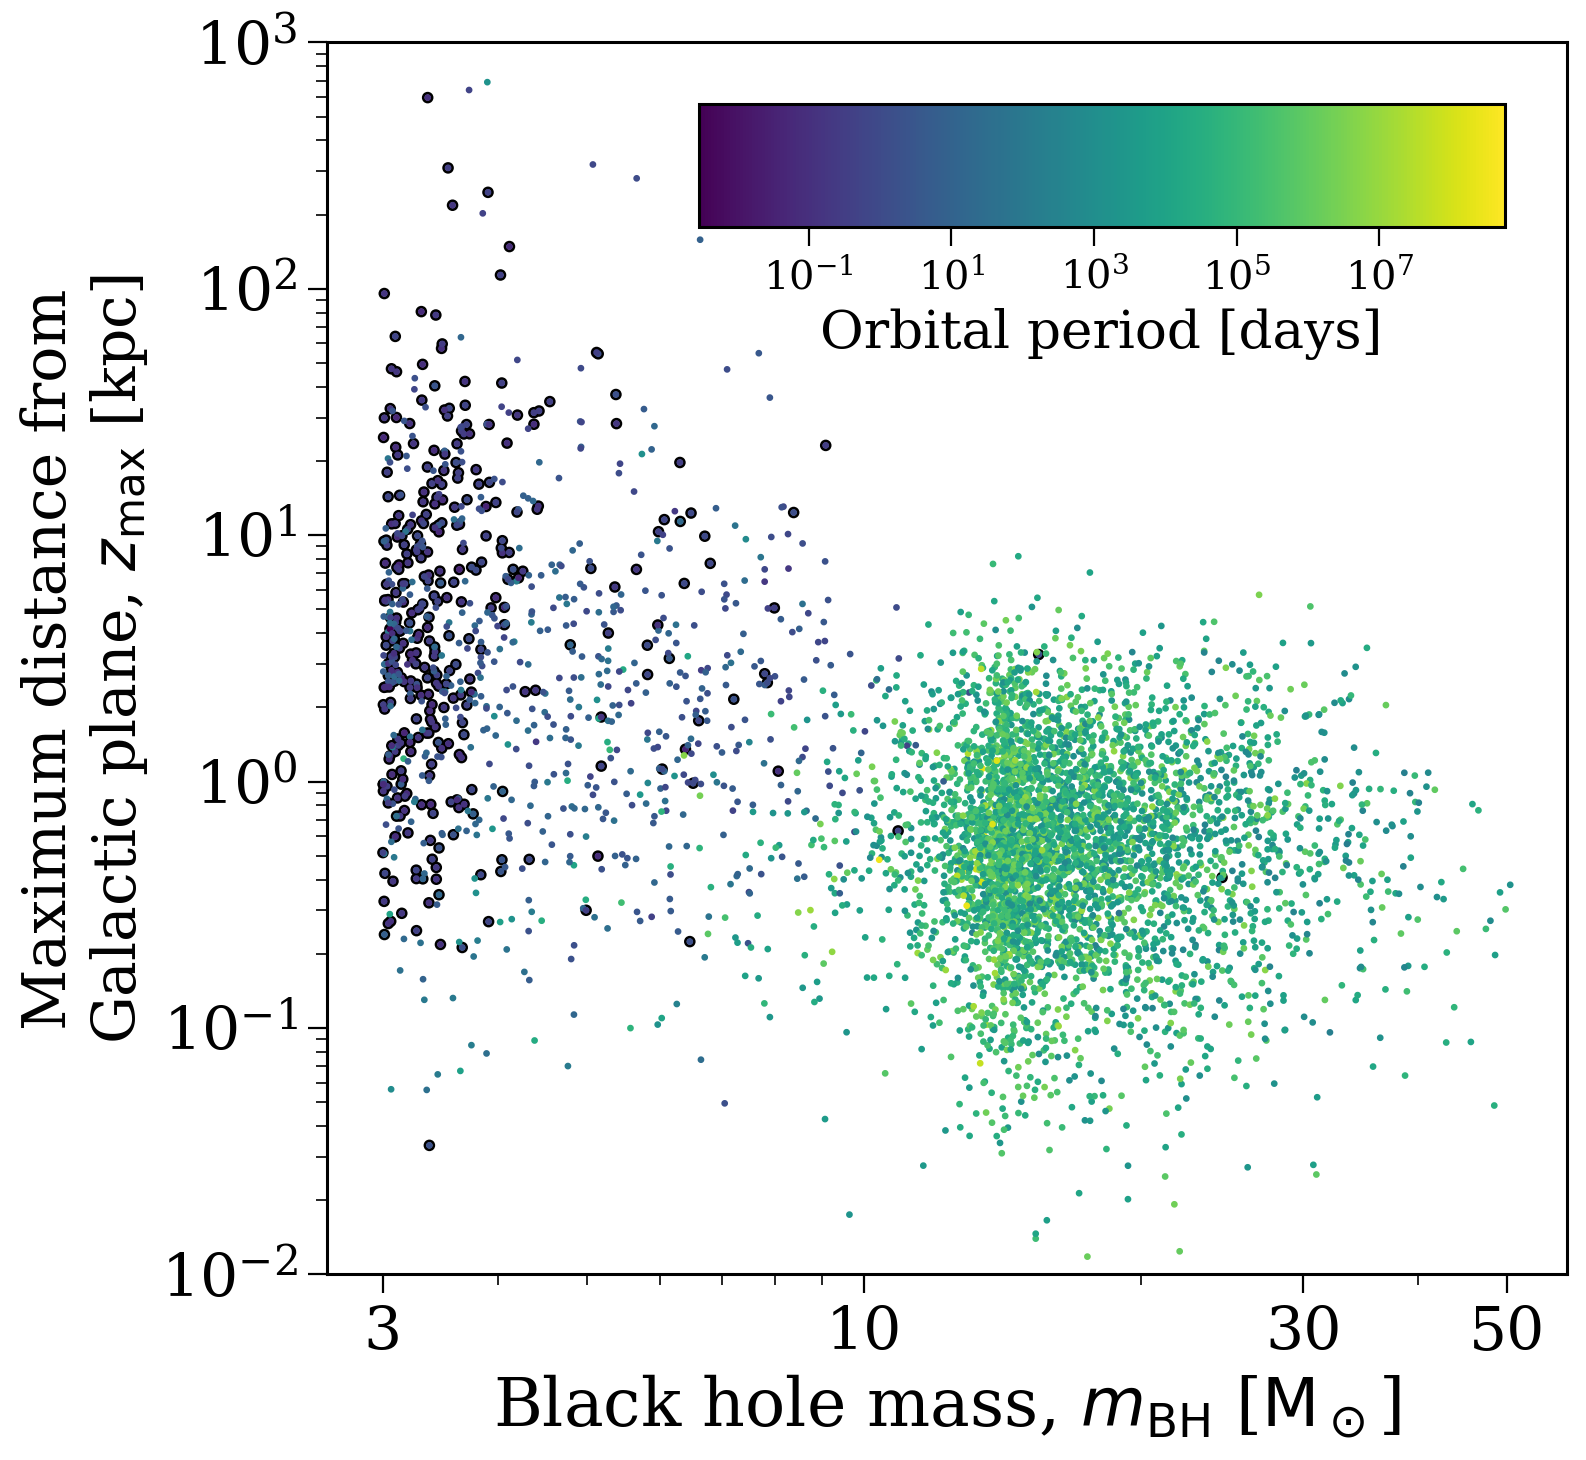

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    bh_star_pop.final_bpp["mass_1"][bh_star_pop.final_bpp["RRLO_2"] > 1.0],
    np.array(z_max)[bh_star_pop.final_bpp["RRLO_2"] > 1.0], s=10, facecolor="none", edgecolor="black",
    rasterized=True
)
scatter = ax.scatter(
    bh_star_pop.final_bpp["mass_1"], z_max, s=2, c=bh_star_pop.final_bpp["porb"],
    norm=mpl.colors.LogNorm(), rasterized=True
)

inset_ax = ax.inset_axes([0.3, 0.85, 0.65, 0.1])
cb = plt.colorbar(scatter, cax=inset_ax, label="Orbital period [days]", orientation="horizontal")
cb.set_label(cb.ax.get_xlabel(), fontsize=0.8*fs)
cb.ax.tick_params(labelsize=0.6*fs)

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Maximum distance from" + "\n" + r"Galactic plane, $z_{\rm max}$ [kpc]",
    xscale="log",
    yscale="log",
    ylim=(1e-2, 1e3),
    xticks=[3, 10, 30, 50],
    xticklabels=[3, 10, 30, 50]
)
ax.set_ylabel(ax.get_ylabel(), fontsize=0.9*fs)

# plt.savefig("../plots/bh_binary_mbh_vs_zmax.pdf", bbox_inches='tight', format='pdf')

plt.show()

In [ ]:
bh_star_pop.final_bpp["mass_1"][bh_star_pop.final_bpp["RRLO_2"] > 1.0].describe()

count    339.000000
mean       3.838946
std        1.682595
min        3.000266
25%        3.141271
50%        3.392109
75%        3.746589
max       24.488580
Name: mass_1, dtype: float64

In [ ]:
bh_star_pop.final_bpp["mass_2"][bh_star_pop.final_bpp["RRLO_2"] > 1.0].describe()

count    339.000000
mean       0.613511
std        0.613103
min        0.101439
25%        0.293021
50%        0.542396
75%        0.767173
max        8.860823
Name: mass_2, dtype: float64